# 🌱💧 **Predicting Irrigation Need**

## 🏆 **Competition Overview**

**Aim**: Build a machine learning model capable of predicting how much irrigation a crop requires, based on environmental conditions.

**Dataset**: The dataset contains synthetically generated records derived from a real-world irrigation dataset. The dataset for this competition (both train and test) was generated from a deep learning model trained on the following dataset: https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data.

**Problem type**: Multiclass classification with three ordered classes: `Low`, `Medium`, and `High`, representing the level of irrigation need. Submissions are evaluated on **balanced accuracy**.

**Citation**: Kaggle Playground Series — Season 6, Episode 4. *Predicting Irrigation Need*. https://www.kaggle.com/competitions/playground-series-s6e4, 2025. Original source: Miadul. *Irrigation Water Requirement Prediction Dataset*. https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset.

---

## 📋 **Index**

**🗂️ 1. [Dataset structure](#ds)**. 

* [A. First steps](#fs). Libraries and data loading.
* [B. Quick overview](#qo). Names, types and missing values.
* [C. Character features](#cf). Check which of them are categorical or binary and encoding.

**🔎 2. [Exploratory Data Analysis (EDA)](#eda)**

* [A. Target Variable - Irrigation Need](#target).
* [B. Univariate & target-oriented analysis](#univar). For each feature we explore its distribution and its relationship with Irrigation_Need.
* [C. Multivariate feature analysis](#multivar).

**🔧 3. [Feature Engineering](#fe)**

**✂️ 4. [Data preparation & preprocessing](#prep)**. Resampling strategy.

**🧠 5. [Modeling](#model)**

* [A. Model specification](#spec)
* [B. Cross-validation evaluation](#cve)
* [C. Compare models](#compare)

**🏆 6. [Final model](#fm)**

**🚀 7. [Submission](#sub)**

---

## 🌾 **Features**

The meaning of each feature is based on the original dataset documentation and personal interpretation:

* **id**. *Numerical*. Row identifier.
* **Soil_Type**. *Categorical - No order*. Type of soil in the field.
    * **Values**: Clay, Loamy, Sandy, Slit.
* **Soil_pH**. *Numerical*. Soil acidity or alkalinity level.
* **Soil_Moisture**. *Numerical*. Water content present in the soil.
* **Organic_Carbon**. *Numerical*. Amount of organic carbon in the soil.
* **Electrical_Conductivity**. *Numerical*. Soil's ability to conduct electrical current, related to salinity.
* **Temperature_C**. *Numerical*. Ambient temperature in degrees Celsius.
* **Humidity**. *Numerical*. Relative humidity as a percentage.
* **Rainfall_mm**. *Numerical*. Rainfall recorded in millimetres.
* **Sunlight_Hours**. *Numerical*. Number of daily sunlight hours.
* **Wind_Speed_kmh**. *Numerical*. Wind speed in kilometres per hour.
* **Crop_Type**. *Categorical - No order*. The crop being grown.
    * **Values**: Cotton, Maize, Potato, Rice, Sugarcabe, Weath.
* **Crop_Growth_Stage**. *Categorical - Order*. Current growth stage of the crop.
    * **Values**:  Sowing < Vegetative < Flowering < Harvest.
* **Season**. *Categorical - No order*. Season in which the observation was recorded.
    * **Values**: Kharif (rainy/monsoon), Rabi (winter), Zaid (short summer).
* **Irrigation_Type**. *Categorical - No order*. Method of irrigation used.
    * **Values**: Canal, Drip, Rainfed, Sprinkler.
* **Water_Source**. *Categorical - No order*. Source of irrigation water.
    * **Values**: Groundwater, Rainwater, Reservoir, River.
* **Field_Area_hectare**. *Numerical*. Field size in hectares.
* **Mulching_Used**. *Binary*. Whether mulching was applied. 
* **Previous_Irrigation_mm**. *Numerical*. Amount of irrigation applied in the previous cycle (mm). 
* **Region**. *Categorical - No order*. Geographic region of the field.
    * **Values**: Central, East, North, South, West.

* **Irrigation_Need**. Target variable. *Categorical - Order*. Irrigation requirement level.
    * **Values**: Low, Medium, High.

---

## 🛠️ **Models to try**

**XGBoost**. Handles class imbalance well, captures non-linear interactions naturally, and is higly tunable.

**LightGBM**. Faster than XGBoost on large datasers. Handles categorical features natively.

**Random Forest**. Robust and less prone to overfitting than boostins. Also provides reliable feature importance estimates.

# **🗂️ 1. Dataset structure** <a class="anchor" id="ds"></a>

## **A. First steps** <a class="anchor" id="fs"></a>

In [1]:
# Libraries

suppressPackageStartupMessages({
  library(tidyverse)  
  library(tidymodels) 
  library(skimr)   
  library(patchwork)
  library(bonsai)
  library(lightgbm)
    
})

In [2]:
# Data loading
train    <- read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv", show_col_types = FALSE)
test     <- read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv", show_col_types = FALSE)

In [3]:
# Other configurations
set.seed(42)
target_fill_colors <- c("Low" = "#8BC34A", "Medium" = "#6BA6D6", "High" = "#D66B70")
target_border_colors <- c("Low" = "#6a9a35", "Medium" = "#4a7fb5", "High" = "#b54a4a")

## **B. Quick overview** <a class="anchor" id="qo"></a>

In [4]:
# COUNTS: Rows and columns
cat("Train:", nrow(train), "rows ·", ncol(train), "columns\n")
cat("Test:", nrow(test), "rows ·", ncol(test), "columns\n")

Train: 630000 rows · 21 columns


Test: 270000 rows · 20 columns


In [5]:
# COLUMN NAMES
print(names(train))

 [1] "id"                      "Soil_Type"              
 [3] "Soil_pH"                 "Soil_Moisture"          
 [5] "Organic_Carbon"          "Electrical_Conductivity"
 [7] "Temperature_C"           "Humidity"               
 [9] "Rainfall_mm"             "Sunlight_Hours"         
[11] "Wind_Speed_kmh"          "Crop_Type"              
[13] "Crop_Growth_Stage"       "Season"                 
[15] "Irrigation_Type"         "Water_Source"           
[17] "Field_Area_hectare"      "Mulching_Used"          
[19] "Previous_Irrigation_mm"  "Region"                 
[21] "Irrigation_Need"        


In [6]:
# DATA TYPES
glimpse(train)

Rows: 630,000
Columns: 21
$ id                      <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, …
$ Soil_Type               <chr> "Loamy", "Clay", "Clay", "Sandy", "Clay", "San…
$ Soil_pH                 <dbl> 4.92, 7.08, 5.69, 5.65, 7.96, 5.09, 7.53, 7.56…
$ Soil_Moisture           <dbl> 32.58, 56.61, 27.71, 13.32, 59.14, 24.70, 49.6…
$ Organic_Carbon          <dbl> 1.01, 0.44, 0.81, 1.33, 0.38, 1.28, 1.44, 0.38…
$ Electrical_Conductivity <dbl> 3.05, 2.00, 2.83, 0.87, 0.96, 0.48, 1.62, 1.31…
$ Temperature_C           <dbl> 15.01, 22.92, 26.97, 13.32, 20.22, 12.21, 14.0…
$ Humidity                <dbl> 50.61, 67.86, 92.22, 61.57, 91.11, 92.35, 61.6…
$ Rainfall_mm             <dbl> 725.99, 985.66, 2201.70, 1357.33, 1538.20, 696…
$ Sunlight_Hours          <dbl> 5.90, 6.98, 6.05, 9.12, 6.95, 9.11, 8.44, 9.96…
$ Wind_Speed_kmh          <dbl> 16.79, 3.39, 3.85, 2.31, 13.94, 7.37, 16.76, 7…
$ Crop_Type               <chr> "Sugarcane", "Wheat", "Rice", "Wheat", "Wheat"…
$ Crop_Growth_

In [7]:
# MISING VALUES

cat("\nMissing values - Train\n")
train %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "feature", values_to = "n_missing") %>%
  filter(n_missing > 0) %>%
  print()

cat("\nMissing values - Test\n")
test %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "feature", values_to = "n_missing") %>%
  filter(n_missing > 0) %>%
  print()


Missing values - Train


# A tibble: 0 × 2
# ℹ 2 variables: feature <chr>, n_missing <int>



Missing values - Test


# A tibble: 0 × 2
# ℹ 2 variables: feature <chr>, n_missing <int>


## **C. Character features** <a class="anchor" id="cf"></a>

In [8]:
chr_features <- train %>%
  select(where(is.character)) %>%
  names()

cat("Unique values per character feature\n\n")
for (f in chr_features) {
  vals <- train %>% pull(f) %>% unique() %>% sort()
  cat(f, paste0("(", length(vals), " unique): "))
  cat(" ", paste(head(vals, 15), collapse = ", "))
  cat("\n")
}

Unique values per character feature



Soil_Type (4 unique):   Clay, Loamy, Sandy, Silt
Crop_Type (6 unique):   Cotton, Maize, Potato, Rice, Sugarcane, Wheat
Crop_Growth_Stage (4 unique):   Flowering, Harvest, Sowing, Vegetative
Season (3 unique):   Kharif, Rabi, Zaid
Irrigation_Type (4 unique):   Canal, Drip, Rainfed, Sprinkler
Water_Source (4 unique):   Groundwater, Rainwater, Reservoir, River
Mulching_Used (2 unique):   No, Yes
Region (5 unique):   Central, East, North, South, West
Irrigation_Need (3 unique):   High, Low, Medium


In [9]:
# Encoding (train and test)

levels_irr <- c("Low", "Medium", "High")
levels_growth <- c("Sowing", "Vegetative", "Flowering", "Harvest")
nominal_features  <- c("Soil_Type", "Crop_Type", "Season",
                        "Irrigation_Type", "Water_Source", "Region")

train <- train %>%
  mutate(
    across(all_of(nominal_features), as.factor),
    Crop_Growth_Stage = factor(Crop_Growth_Stage, levels = levels_growth, ordered = TRUE),
    Mulching_Used     = Mulching_Used == "Yes",
    Irrigation_Need   = factor(Irrigation_Need,   levels = levels_irr,    ordered = TRUE)
  )

test <- test %>%
  mutate(
    across(all_of(nominal_features), as.factor),
    Crop_Growth_Stage = factor(Crop_Growth_Stage, levels = levels_growth, ordered = TRUE),
    Mulching_Used     = Mulching_Used == "Yes"
  )

# **🔎 2. Exploratory Data Analysis (EDA)** <a class="anchor" id="eda"></a>

## **A. Target variable — Irrigation_Need** <a class="anchor" id="target"></a>

In [10]:
# CLASS BALANCE
train %>%
  count(Irrigation_Need) %>%
  mutate(pct = n / sum(n) * 100) %>%
  print()

# A tibble: 3 × 3
  Irrigation_Need      n   pct
  <ord>            <int> <dbl>
1 Low             369917 58.7 
2 Medium          239074 37.9 
3 High             21009  3.33


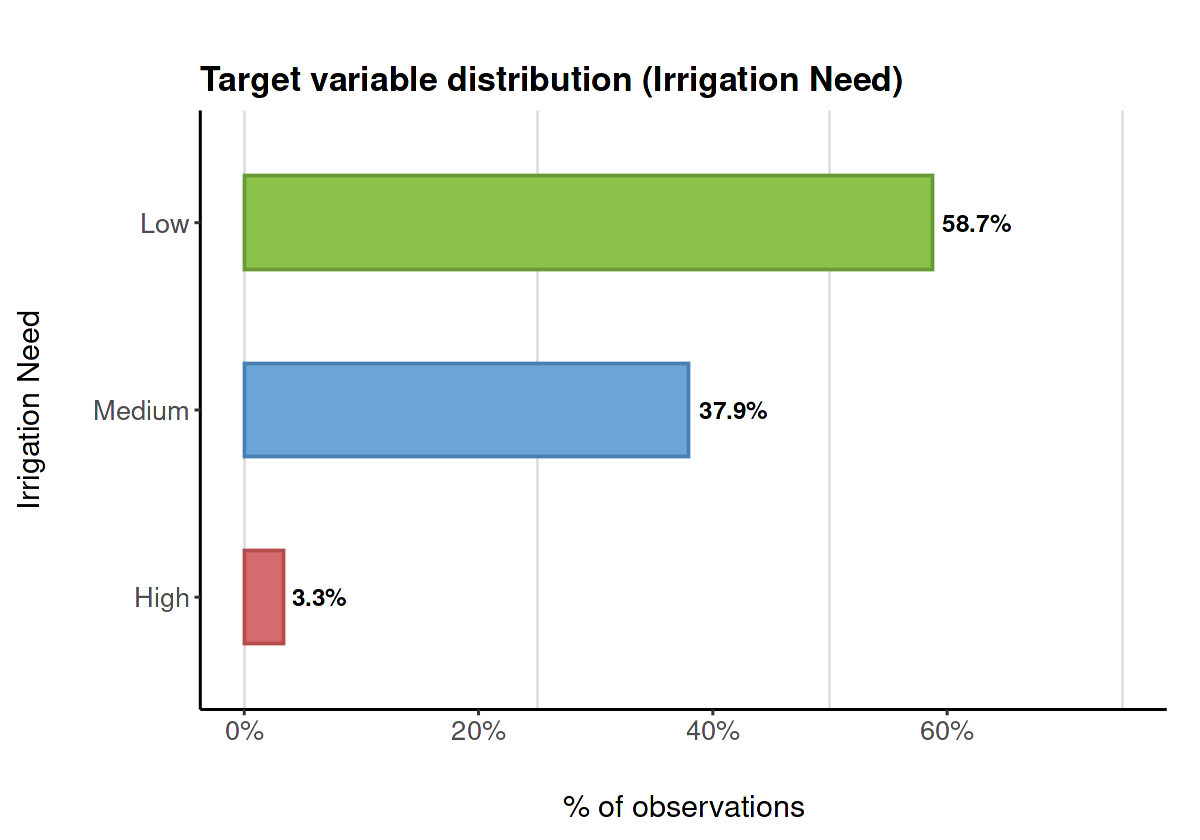

In [11]:
options(repr.plot.width = 10, repr.plot.height = 7)

train %>%
  count(Irrigation_Need) %>%
  mutate(pct = n / sum(n) * 100) %>%
  ggplot(aes(y = fct_rev(Irrigation_Need), x = pct, fill = Irrigation_Need,
             color = Irrigation_Need)) +
  geom_vline(xintercept = seq(0, 75, by = 25), color = "grey85", linewidth = 0.5) +
  geom_col(width = 0.5, show.legend = FALSE, linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.1f%%", pct)),
            hjust = -0.15, size = 5, fontface = "bold", color = "black") +
  scale_fill_manual(values = target_fill_colors) +
  scale_color_manual(values = target_border_colors) +
  scale_x_continuous(limits = c(0, 75),
                     labels = scales::label_percent(scale = 1)) +
  labs(
    title = "Target variable distribution (Irrigation Need)",
    x     = "% of observations",
    y     = "Irrigation Need"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title  = element_text(face = "bold", size = 20),
    axis.title.x = element_text(size = 18, margin = margin(t = 30)),
    axis.title.y = element_text(size = 18, margin = margin(r = 30)),
    axis.text   = element_text(size = 16),
    plot.margin  = margin(t = 40, r = 20, b = 10, l = 10)  
  )

#### **<u>Target Conclusions</u>**

In multiclass problems evaluated with balanced accuracy, class imbalance is critical. Balanced accuracy penalizes models that ignore minority classes, so understanding the distribution of `Irrigation_Need` guides the resampling and modeling strategy.

**Conclusion**: The dataset is **heavily imbalanced**. 
* `Low` dominates with 58.7% of observations.`Medium` represents 37.9%. `High` is a minority class with only 3.3%.
* Since the competition metric is **balanced accuracy**, the model is equally penalized for errors on each class regardless of its frequency. This means we must ensure `High` well represented in every cross-validation fold and consider class weights during modeling to avoid the model systematically ignoring the minority class.

## **B. Univariate - target-oriented analysis** <a class="anchor" id="univar"></a>

### **Numerical features**

**Univariate distribution**. Overall shape,central tendency, and spread. Histogram + density curve.

**Target-oriented analysis**. Looking for shifts in location or spread across the three classes that could be predictive. Boxplot per class.

In [12]:
# Univariate summary statistics
numerical_features <- c("Soil_pH", "Soil_Moisture", "Organic_Carbon",
                         "Electrical_Conductivity", "Temperature_C", "Humidity",
                         "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh",
                         "Field_Area_hectare", "Previous_Irrigation_mm")

train %>%
  select(all_of(numerical_features)) %>%
  pivot_longer(everything(), names_to = "feature", values_to = "value") %>%
  group_by(feature) %>%
  summarise(
    n      = n(),
    mean   = mean(value,             na.rm = TRUE),
    sd     = sd(value,               na.rm = TRUE),
    min    = min(value,              na.rm = TRUE),
    q25    = quantile(value, 0.25,   na.rm = TRUE),
    median = median(value,           na.rm = TRUE),
    q75    = quantile(value, 0.75,   na.rm = TRUE),
    max    = max(value,              na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(across(where(is.numeric), ~ round(., 3))) %>%
  arrange(feature) %>%
  { options(width = 200); print(as.data.frame(.), row.names = FALSE) }

                 feature      n     mean      sd   min     q25  median     q75     max
 Electrical_Conductivity 630000    1.745   0.952  0.10   0.930    1.74    2.58    3.50
      Field_Area_hectare 630000    7.518   4.218  0.30   3.880    7.38   11.14   15.00
                Humidity 630000   61.563  19.708 25.00  45.390   61.65   79.12   94.99
          Organic_Carbon 630000    0.923   0.366  0.30   0.610    0.91    1.22    1.60
  Previous_Irrigation_mm 630000   62.318  34.247  0.02  33.140   61.15   92.69  119.99
             Rainfall_mm 630000 1462.208 612.990  0.38 954.570 1467.16 2054.28 2499.69
           Soil_Moisture 630000   37.304  16.377  8.00  23.340   37.75   51.27   64.99
                 Soil_pH 630000    6.482   0.923  4.80   5.690    6.44    7.27    8.20
          Sunlight_Hours 630000    7.513   1.999  4.00   5.760    7.58    9.25   11.00
           Temperature_C 630000   26.998   8.624 12.00  19.518   26.96   34.54   42.00
          Wind_Speed_kmh 630000   10.375   

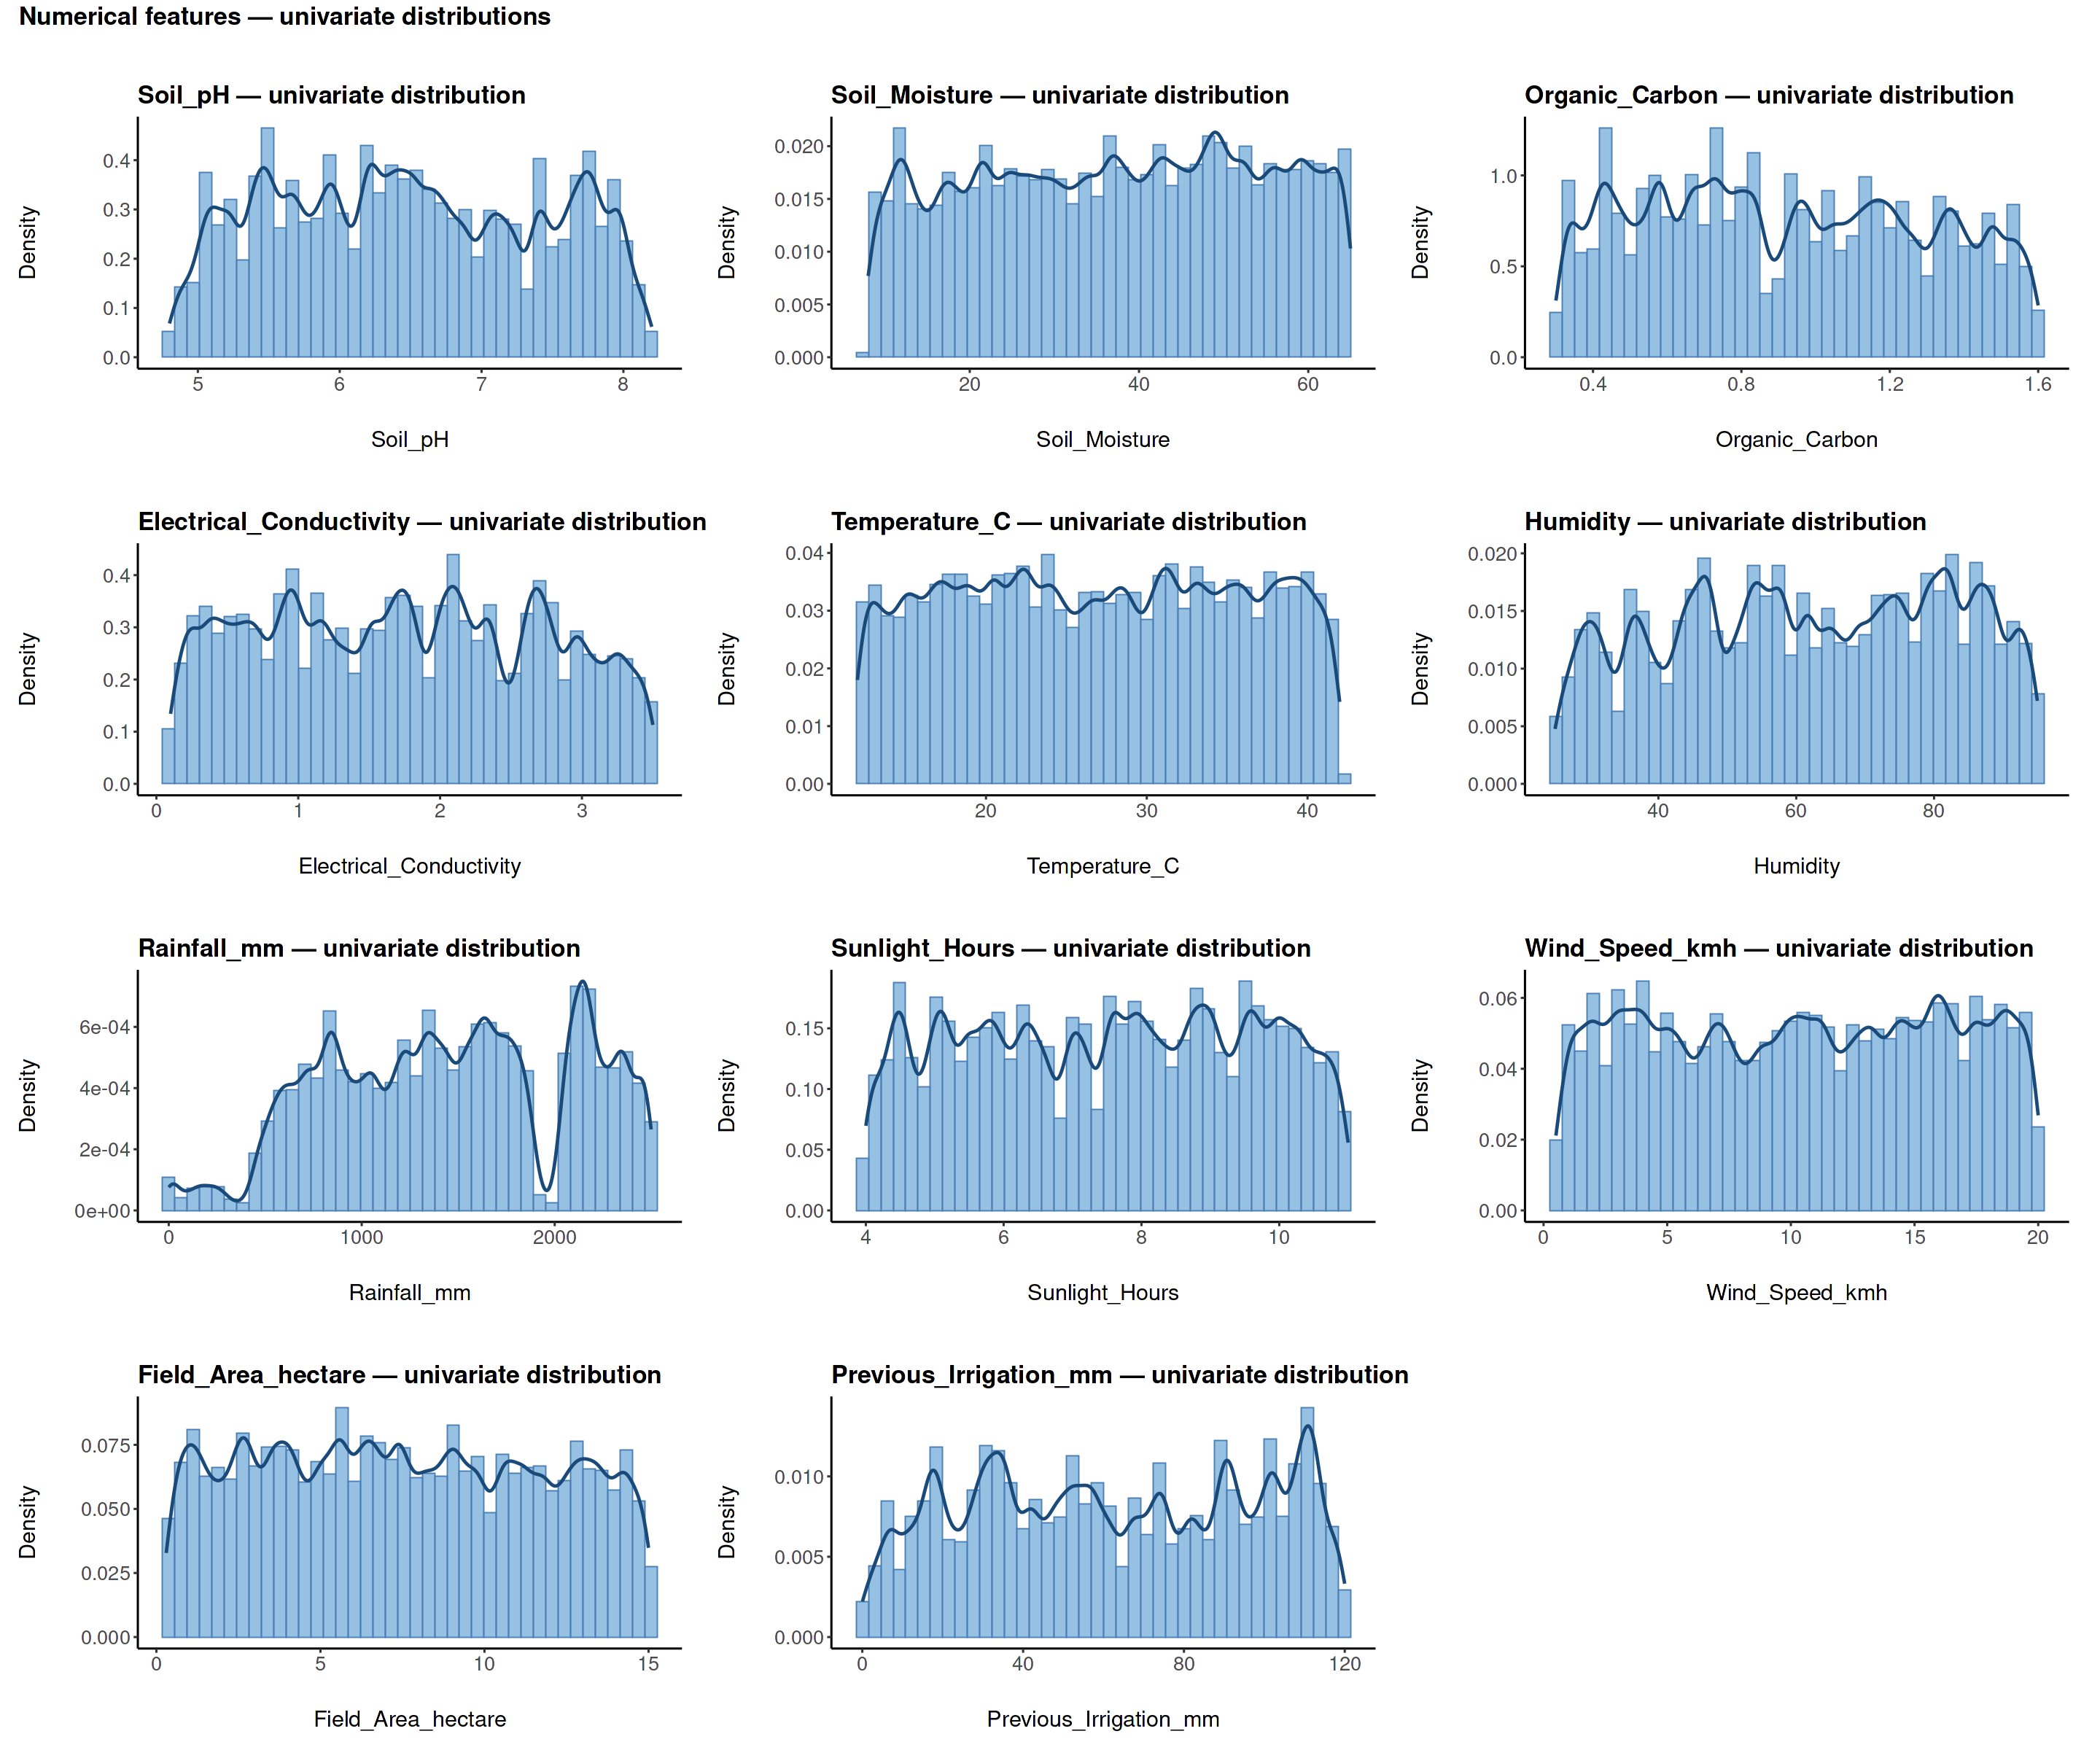

In [13]:
# Univariate plot: histogram + density curve
options(repr.plot.width = 24, repr.plot.height = 20)

plot_univariate <- function(df, feature) {
  df %>%
    ggplot(aes(x = .data[[feature]])) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = 40, fill = "#6BA6D6",
                   color = "#4a7fb5", linewidth = 0.4, alpha = 0.7) +
    geom_density(linewidth = 1, color = "#1a4a7a") +
    labs(
      title = paste0(feature, " — univariate distribution"),
      x     = feature,
      y     = "Density"
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title   = element_text(face = "bold", size = 20),
      axis.title.x = element_text(size = 18, margin = margin(t = 30)),
      axis.title.y = element_text(size = 18, margin = margin(r = 30)),
      axis.text    = element_text(size = 16),
      plot.margin  = margin(t = 40, r = 20, b = 10, l = 10)
    )
}

plots_univariate <- map(numerical_features, ~ plot_univariate(train, .x))

wrap_plots(plots_univariate, ncol = 3) +
  plot_annotation(
    title   = "Numerical features — univariate distributions",
    theme   = theme(
      plot.title = element_text(face = "bold", size = 20)
    )
  )

In [14]:
# Target-oriented summary statistics

train %>%
  select(all_of(numerical_features), Irrigation_Need) %>%
  pivot_longer(cols = all_of(numerical_features),
               names_to  = "feature",
               values_to = "value") %>%
  group_by(feature, Irrigation_Need) %>%
  summarise(
    mean   = mean(value,           na.rm = TRUE),
    sd     = sd(value,             na.rm = TRUE),
    median = median(value,         na.rm = TRUE),
    q25    = quantile(value, 0.25, na.rm = TRUE),
    q75    = quantile(value, 0.75, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(across(where(is.numeric), ~ round(., 3))) %>%
  pivot_wider(
    names_from  = Irrigation_Need,
    values_from = c(mean, sd, median, q25, q75),
    names_glue  = "{Irrigation_Need}_{.value}"
  ) %>%
  select(feature,
         starts_with("Low"),
         starts_with("Medium"),
         starts_with("High")) %>%
  arrange(feature) %>%
  { options(width = 200); print(as.data.frame(.), row.names = FALSE) }

                 feature Low_mean  Low_sd Low_median Low_q25 Low_q75 Medium_mean Medium_sd Medium_median Medium_q25 Medium_q75 High_mean High_sd High_median High_q25 High_q75
 Electrical_Conductivity    1.732   0.961       1.72    0.90    2.58       1.769     0.943          1.76       0.97       2.59     1.691   0.891        1.65     0.95     2.37
      Field_Area_hectare    7.447   4.197       7.25    3.90   11.04       7.626     4.225          7.56       3.90      11.23     7.530   4.477        7.49     3.40    11.66
                Humidity   61.949  19.913      61.77   44.94   79.45      61.005    19.414         61.44      46.23      78.54    61.120  19.243       62.85    47.55    77.16
          Organic_Carbon    0.921   0.366       0.90    0.61    1.22       0.926     0.365          0.93       0.61       1.23     0.924   0.374        0.91     0.58     1.25
  Previous_Irrigation_mm   61.718  35.548      59.38   30.95   94.90      63.182    32.295         62.20      34.87      90.4

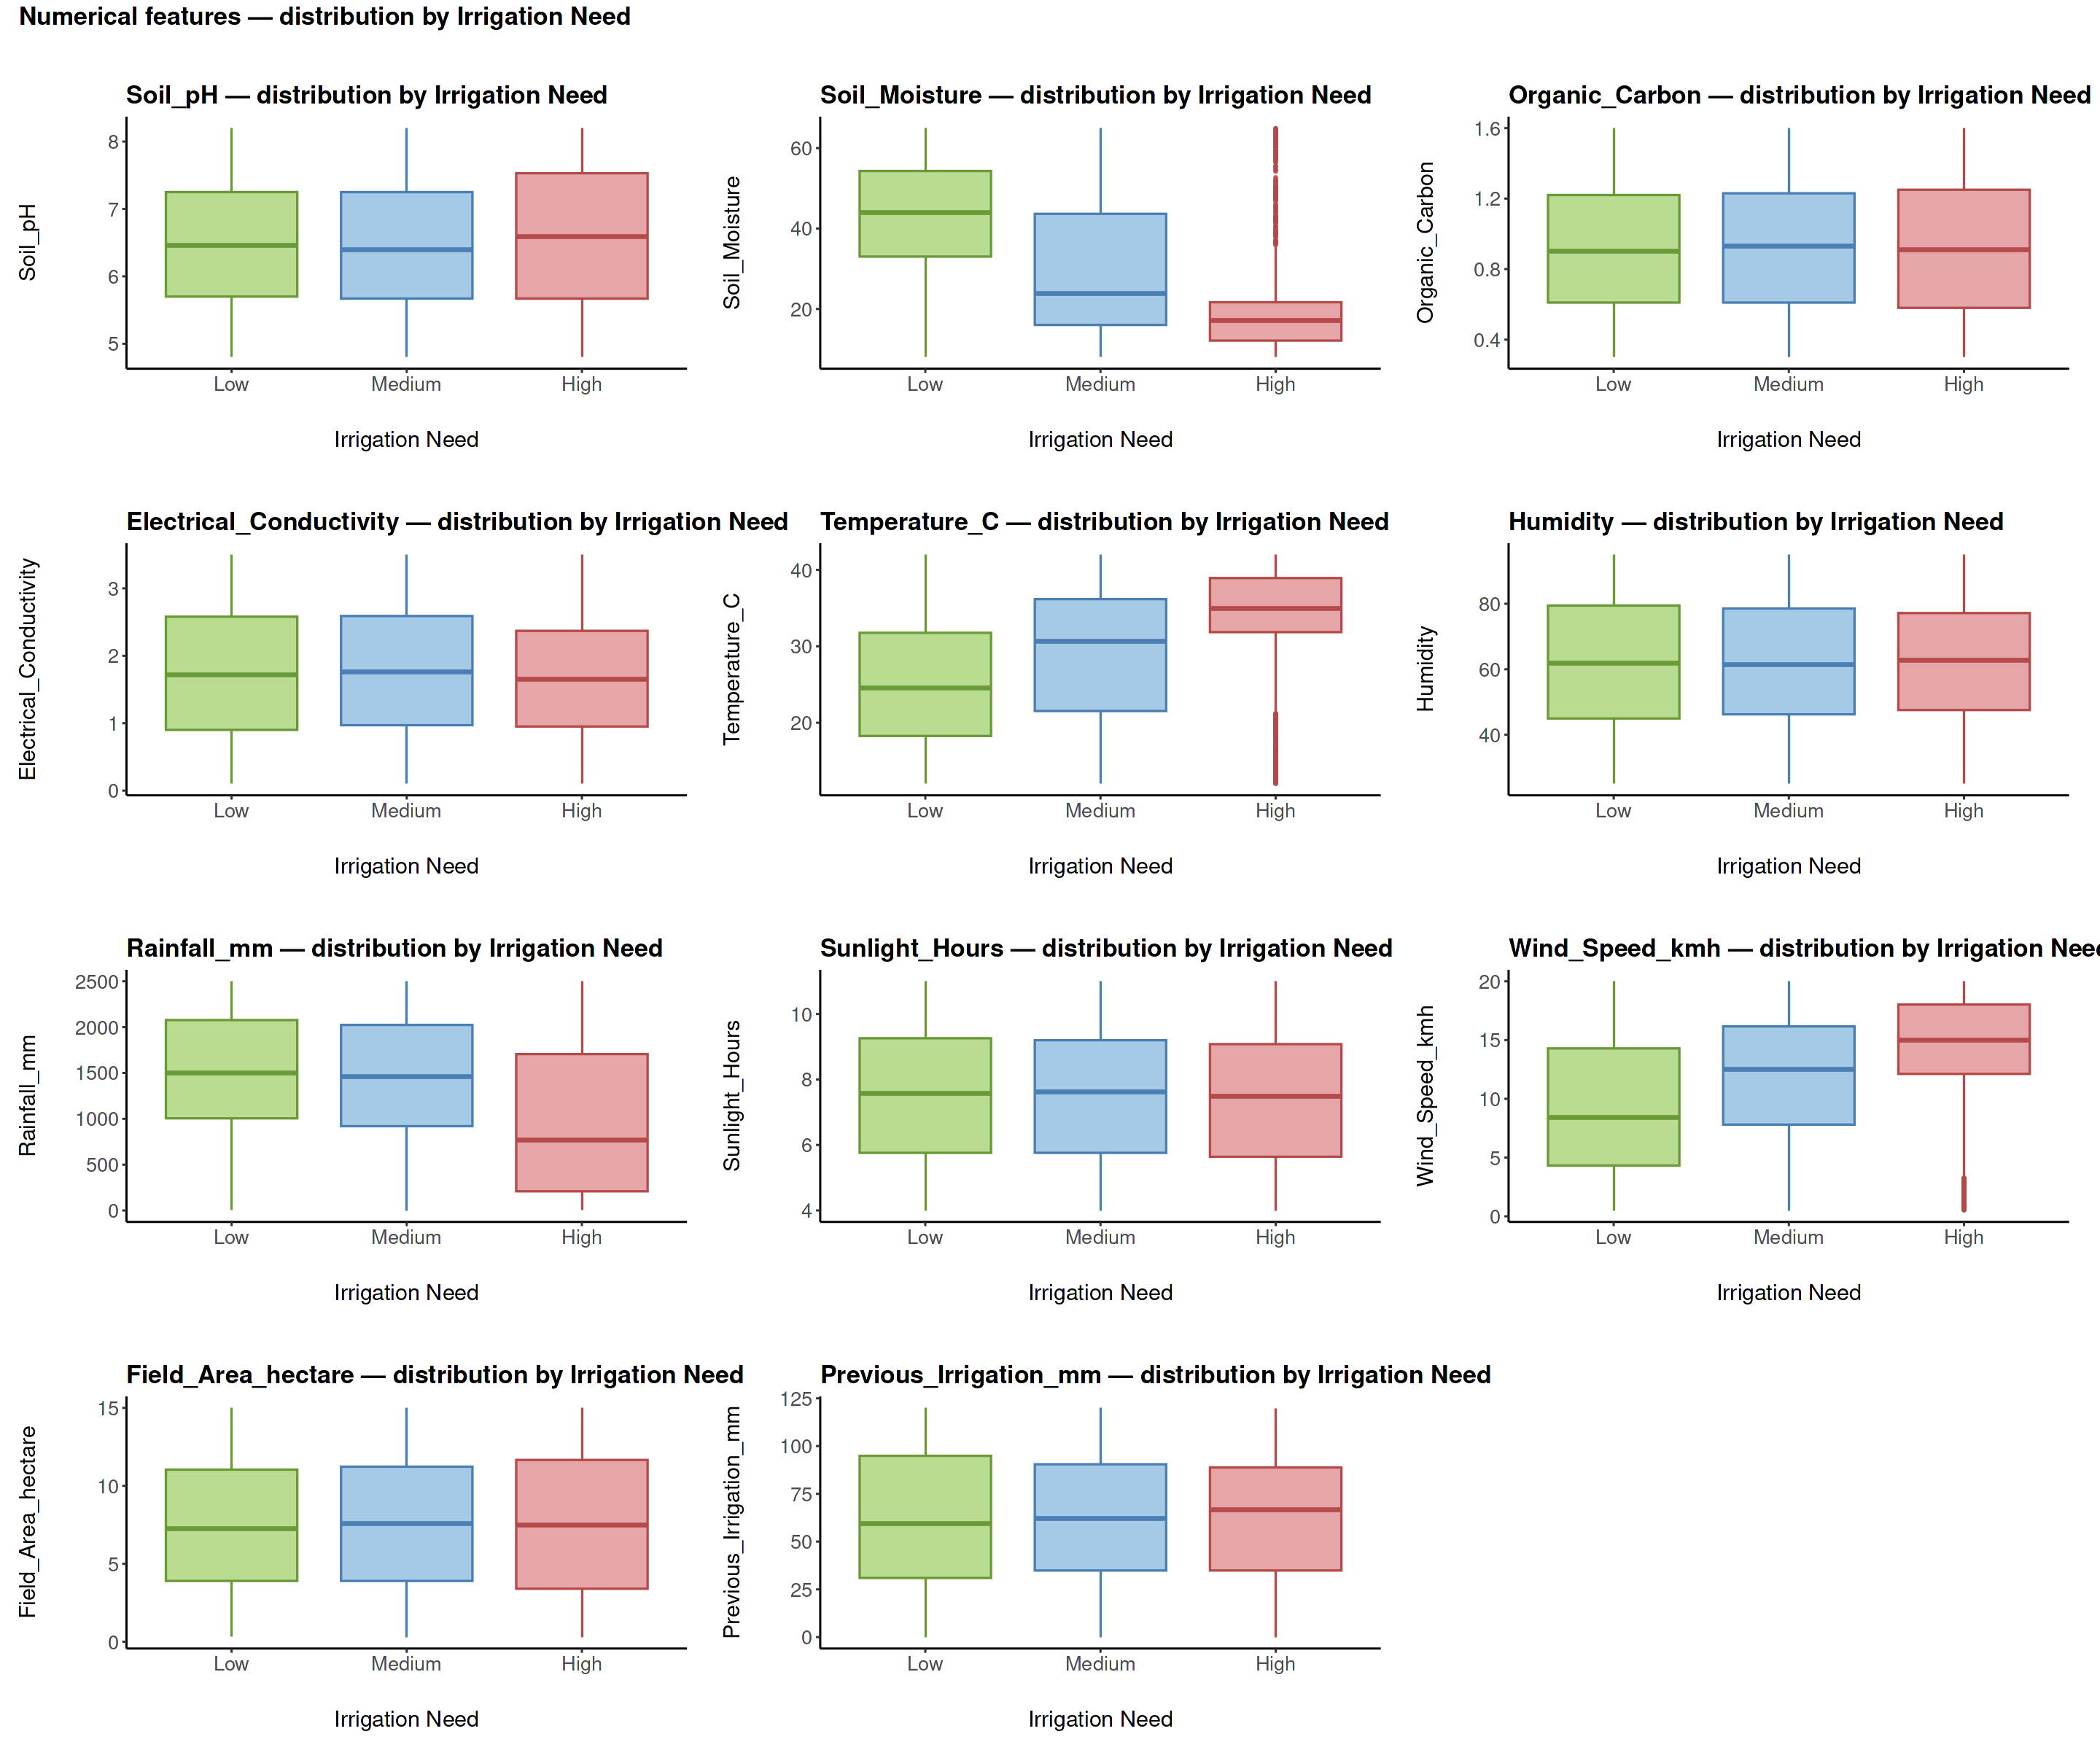

In [15]:
# Target-oriented plot: boxplot per class

options(repr.plot.width = 24, repr.plot.height = 20)

plot_by_target <- function(df, feature) {
  df %>%
    ggplot(aes(x = Irrigation_Need, y = .data[[feature]],
               fill = Irrigation_Need, color = Irrigation_Need)) +
    geom_boxplot(alpha = 0.6, linewidth = 0.7, outlier.size = 0.8,
                 outlier.alpha = 0.4) +
    scale_fill_manual(values  = target_fill_colors) +
    scale_color_manual(values = target_border_colors) +
    labs(
      title = paste0(feature, " — distribution by Irrigation Need"),
      x     = "Irrigation Need",
      y     = feature
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title   = element_text(face = "bold", size = 20),
      axis.title.x = element_text(size = 18, margin = margin(t = 30)),
      axis.title.y = element_text(size = 18, margin = margin(r = 30)),
      axis.text    = element_text(size = 16),
      plot.margin  = margin(t = 40, r = 20, b = 10, l = 10),
      legend.position = "none"
    )
}

plots_by_target <- map(numerical_features, ~ plot_by_target(train, .x))

wrap_plots(plots_by_target, ncol = 3) +
  plot_annotation(
    title = "Numerical features — distribution by Irrigation Need",
    theme = theme(
      plot.title = element_text(face = "bold", size = 20)
    )
  )

#### **<u>Numerical Features Conclusions</u>**

<br>

**Predictive power scale:**
&nbsp; <span style="background-color: #8BC34A; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Strong predictor</span> &nbsp;&nbsp;
<span style="background-color: #6BA6D6; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Moderate predictor</span> &nbsp;&nbsp;
<span style="background-color: #FFB74D; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Weak predictor</span>

<br>

---

<span style="background-color: #6BA6D6; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Soil_pH</span>

* **Univariate**. Ranges from 4.8 to 8.2 with a mean of 6.48, covering the full spectrum from acidic to slightly alkaline soils. The distribution is roughly uniform with no strong central tendency.
* **Target relationship**: Minimal differences across classes (Low: 6.49, Medium: 6.47, High: 6.58). The boxplots confirm near-identical distributions. 

<br>

<span style="background-color: #8BC34A; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Soil_Moisture</span>

* **Univariate**: Ranges from 8 to 65 with a mean of 37.3. The distribution is approximately uniform, suggesting moisture levels are well spread across the dataset.
* **Target relationship**: Strong and clear separation. Low irrigation need corresponds to high moisture (mean 43.3), Medium to moderate moisture (mean 29.7), and High to very low moisture (mean 17.7). This makes intuitive sense: drier soils require more irrigation.

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Organic_Carbon</span>

* **Univariate**: Ranges from 0.3 to 1.6 with a mean of 0.92. Roughly symmetric and uniformly distributed.
* **Target relationship**: Virtually identical distributions across all three classes (means: 0.921, 0.926, 0.924). 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Electrical_Conductivity</span>

* **Univariate**: Ranges from 0.1 to 3.5 with a mean of 1.75, distributed fairly uniformly across its range.
* **Target relationship**: No meaningful difference between classes (means: 1.73, 1.77, 1.69).

<br>

<span style="background-color: #8BC34A; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Temperature_C</span>

* **Univariate**: Ranges from 12 to 42°C with a mean of 27°C and a wide standard deviation of 8.6, suggesting observations span multiple climate conditions.
* **Target relationship**: Clear monotonic increase across classes. Low mean of 25.3°C, Medium 28.9°C, and High 34.6°C. Higher temperatures increase evapotranspiration and therefore irrigation demand. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Humidity</span>

* **Univariate**: Ranges from 25% to 95% with a mean of 61.6% and a wide spread (sd = 19.7), covering dry to very humid conditions.
* **Target relationship**: Marginal differences across classes (Low: 61.9%, Medium: 61.0%, High: 61.1%). The boxplots confirm nearly identical distributions. 

<br>

<span style="background-color: #6BA6D6; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Rainfall_mm</span>

* **Univariate**: Ranges from 0.4 to 2,500mm with a mean of 1,462mm. The distribution appears bimodal, suggesting the dataset contains observations from both low and high rainfall environments.
* **Target relationship**: Notable separation, especially for the High class. Low mean of 1,500mm, Medium 1,444mm, and High drops sharply to 990mm. Areas with less rainfall naturally require more irrigation. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Sunlight_Hours</span>

* **Univariate**: Ranges from 4 to 11 hours with a mean of 7.5 and a relatively symmetric distribution.
* **Target relationship**: Nearly identical distributions across all three classes (means: 7.51, 7.52, 7.46). 

<br>

<span style="background-color: #6BA6D6; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Wind_Speed_kmh</span>

* **Univariate**: Ranges from 0.5 to 20 km/h with a mean of 10.4. The distribution is approximately uniform.
- **Target relationship**: Clear increasing trend. Low mean of 9.2 km/h, Medium 11.8 km/h, and High 14.6 km/h. Higher wind speeds increase evapotranspiration, raising irrigation demand. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Field_Area_hectare</span>

* **Univariate**: Ranges from 0.3 to 15 hectares with a mean of 7.5, distributed uniformly across its range.
* **Target relationship**: Almost no difference across classes (means: 7.45, 7.63, 7.53). Field size alone does not determine irrigation need. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Previous_Irrigation_mm</span>

* **Univariate**: Ranges from 0 to 120mm with a mean of 62.3. The distribution is approximately uniform and symmetric.
* **Target relationship**: Slight differences (Low: 61.7mm, Medium: 63.2mm, High: 63.1mm), but the boxplots show largely overlapping distributions. 

<br>

---

#### **<u>Overall summarys</u>**

The four features that stand out, `Soil_Moisture`, `Temperature_C`, `Rainfall_mm`, and `Wind_Speed_kmh`, are all relate directly to the water balance of the field: *how much water is available in the soil, how fast it evaporates, and how much arrives naturally and through rain*. 

### **Categorical features**

**Univariate distribution**. Counts and percentages for each category within each feature. Bar chart.

**Target-oriented analysis**. Percentage of each target class within each category. Stacked Bar chart.

In [16]:
# Global frequency table
categorical_features <- c("Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season", "Irrigation_Type", "Water_Source", "Mulching_Used", "Region")

train %>%
  select(all_of(categorical_features)) %>%
  mutate(across(everything(), as.character)) %>%
  pivot_longer(everything(), names_to = "feature", values_to = "category") %>%
  count(feature, category) %>%
  group_by(feature) %>%
  mutate(pct = round(n / sum(n) * 100, 2)) %>%
  ungroup() %>%
  arrange(feature, desc(n)) %>%
  { options(width = 200); print(as.data.frame(.), row.names = FALSE) }

           feature    category      n   pct
 Crop_Growth_Stage     Harvest 167689 26.62
 Crop_Growth_Stage   Flowering 157563 25.01
 Crop_Growth_Stage  Vegetative 157246 24.96
 Crop_Growth_Stage      Sowing 147502 23.41
         Crop_Type   Sugarcane 108910 17.29
         Crop_Type        Rice 106697 16.94
         Crop_Type      Cotton 104645 16.61
         Crop_Type       Maize 104274 16.55
         Crop_Type       Wheat 103005 16.35
         Crop_Type      Potato 102469 16.26
   Irrigation_Type       Canal 161901 25.70
   Irrigation_Type   Sprinkler 161400 25.62
   Irrigation_Type     Rainfed 155607 24.70
   Irrigation_Type        Drip 151092 23.98
     Mulching_Used       FALSE 316453 50.23
     Mulching_Used        TRUE 313547 49.77
            Region       South 134809 21.40
            Region        West 131189 20.82
            Region        East 126163 20.03
            Region     Central 123712 19.64
            Region       North 114127 18.12
            Season      Kharif 2

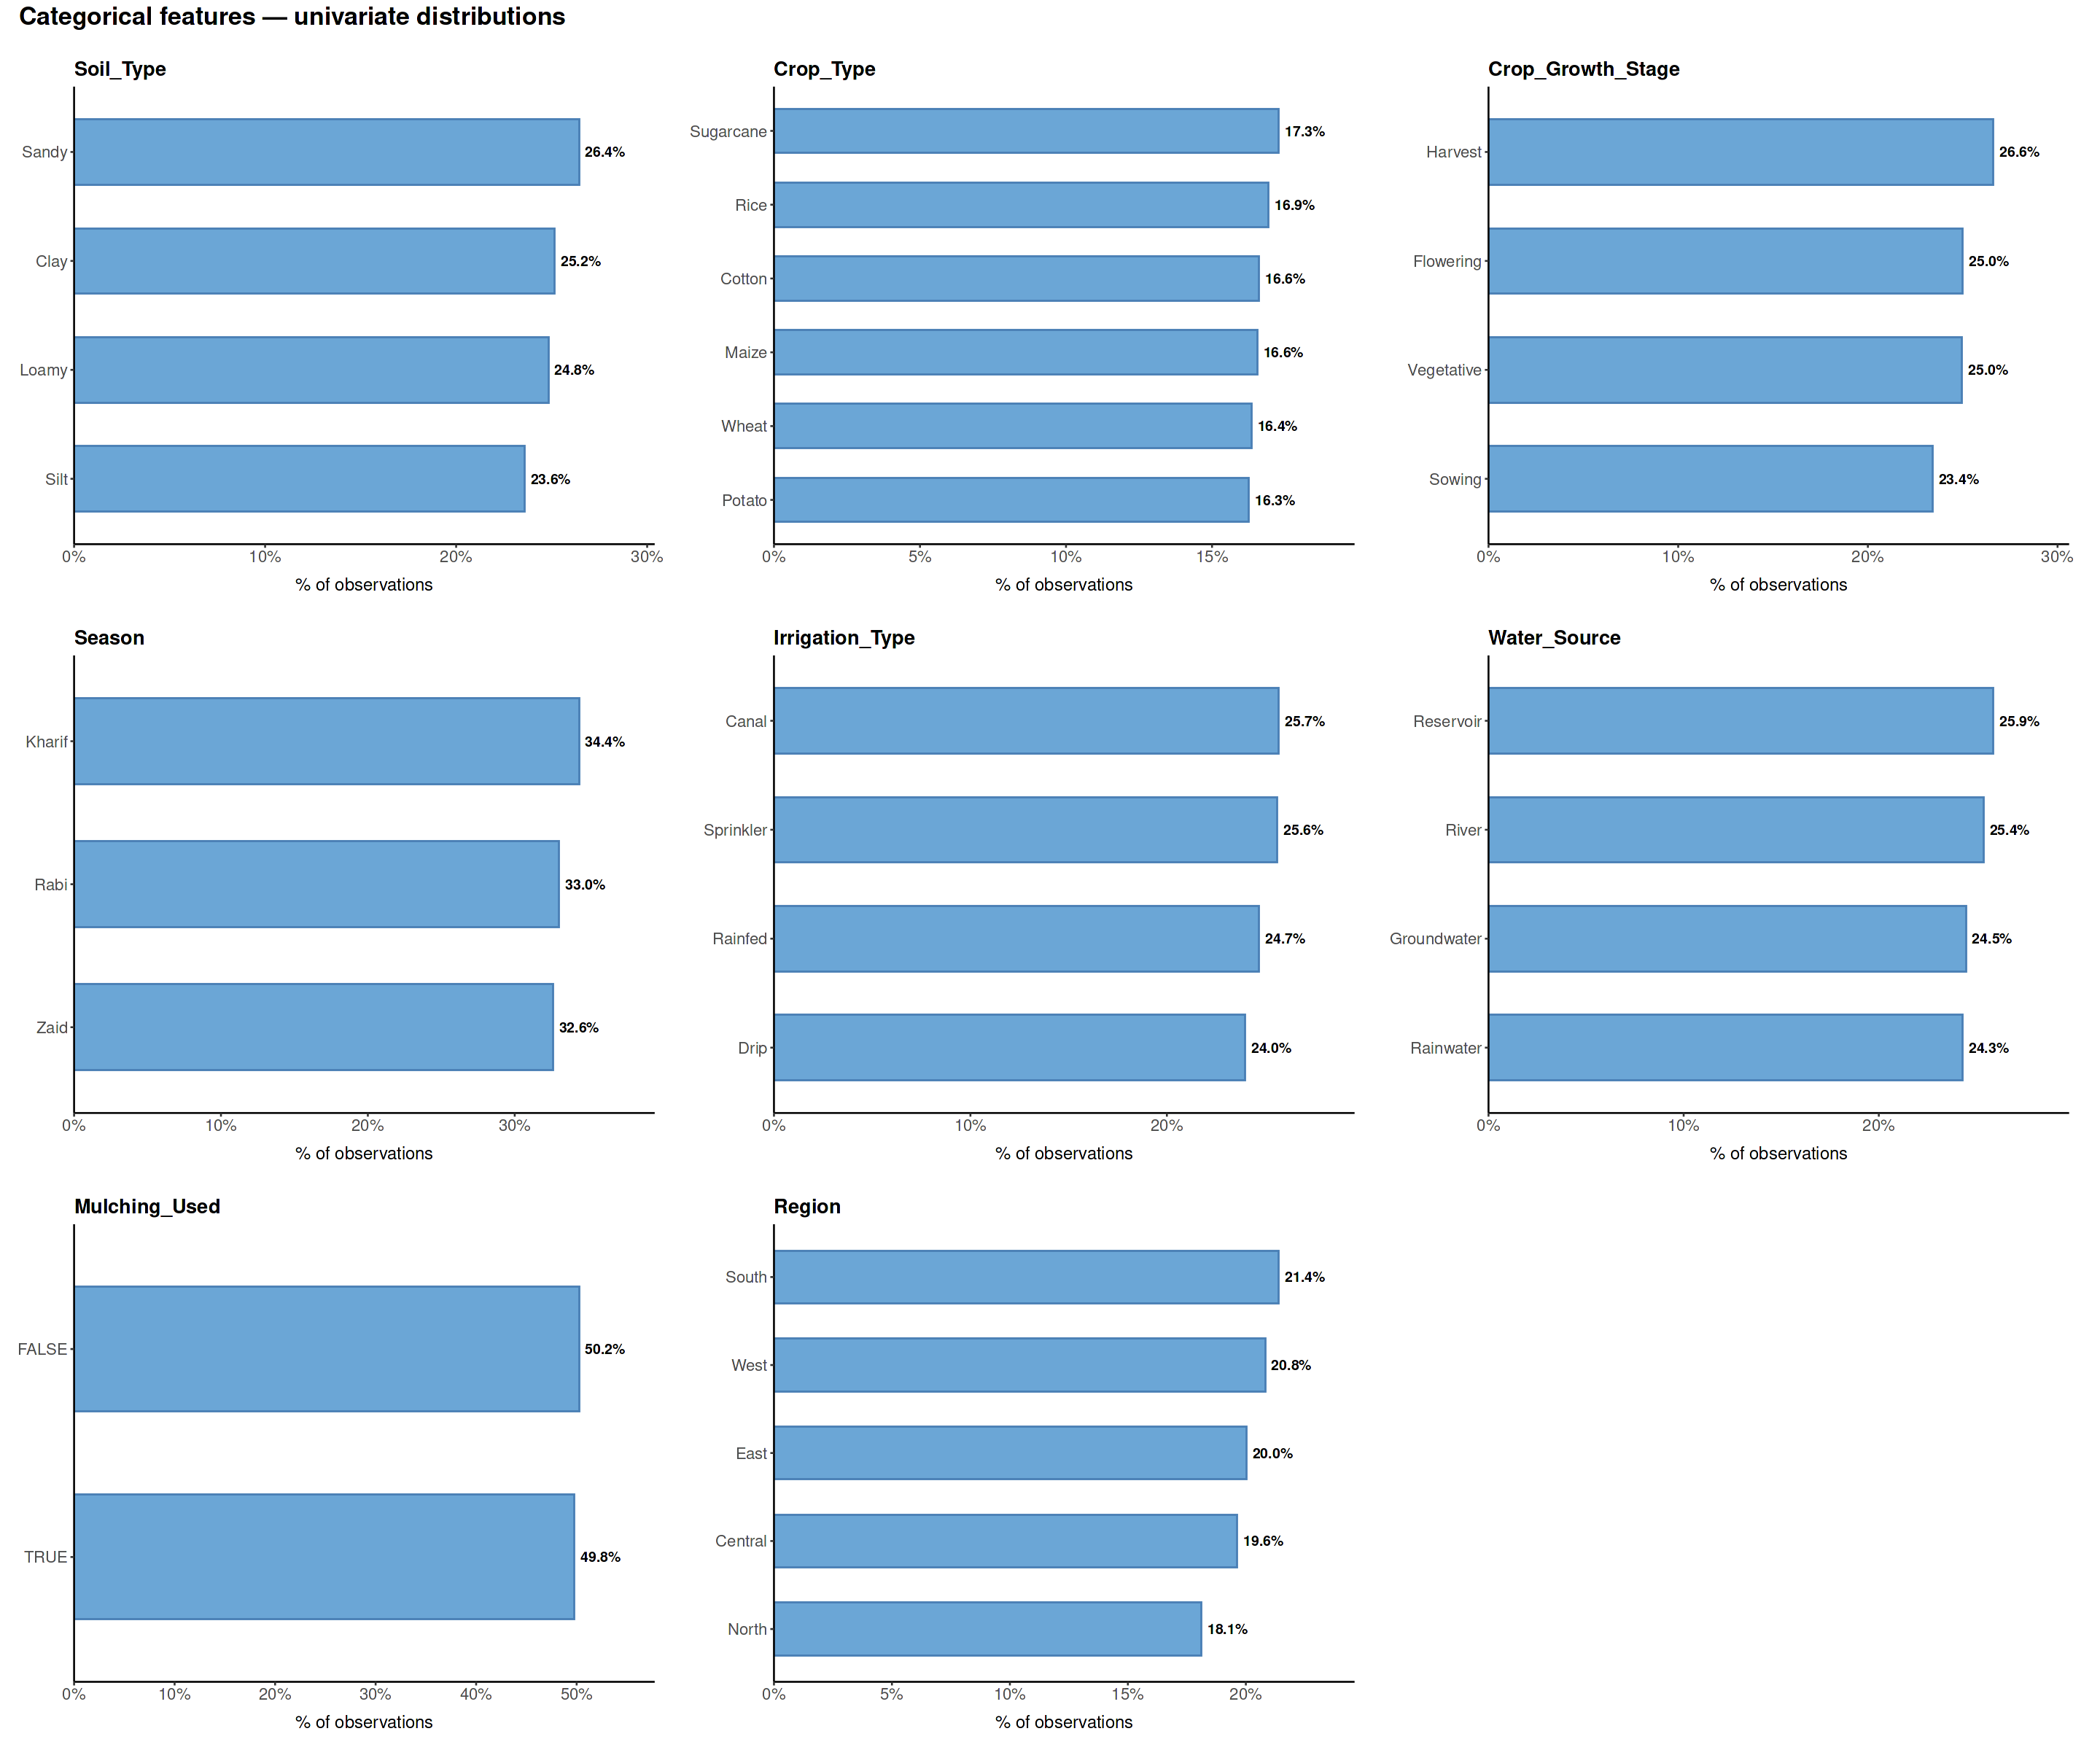

In [17]:
# Univariate plots

options(repr.plot.width = 24, repr.plot.height = 20)

plot_cat_univariate <- function(df, feature) {
  df %>%
    mutate(cat = as.character(.data[[feature]])) %>%
    count(cat) %>%
    mutate(pct = n / sum(n) * 100,
           cat = fct_reorder(cat, pct)) %>%
    ggplot(aes(y = cat, x = pct)) +
    geom_col(width = 0.6, fill = "#6BA6D6", color = "#4a7fb5", linewidth = 0.6) +
    geom_text(aes(label = sprintf("%.1f%%", pct)),
              hjust = -0.15, size = 4, fontface = "bold", color = "black") +
    scale_x_continuous(limits = c(0, NA),
                   labels = scales::label_percent(scale = 1),
                   expand = expansion(mult = c(0, 0.15))) +
    labs(title = feature, x = "% of observations", y = NULL) +
    theme_classic(base_size = 12) +
    theme(
      plot.title   = element_text(face = "bold", size = 16),
      axis.title.x = element_text(size = 14, margin = margin(t = 10)),
      axis.text    = element_text(size = 13),
      plot.margin  = margin(t = 20, r = 20, b = 10, l = 10)
    )
}

plots_cat_univariate <- map(categorical_features, ~ plot_cat_univariate(train, .x))

wrap_plots(plots_cat_univariate, ncol = 3) +
  plot_annotation(
    title = "Categorical features — univariate distributions",
    theme = theme(plot.title = element_text(face = "bold", size = 20))
  )

In [18]:
# Target-oriented table

train %>%
  select(all_of(categorical_features), Irrigation_Need) %>%
  mutate(across(all_of(categorical_features), as.character)) %>%
  pivot_longer(cols = all_of(categorical_features),
               names_to  = "feature",
               values_to = "category") %>%
  count(feature, category, Irrigation_Need) %>%
  group_by(feature, category) %>%
  mutate(pct = round(n / sum(n) * 100, 2)) %>%
  ungroup() %>%
  select(-n) %>%
  pivot_wider(names_from  = Irrigation_Need,
              values_from = pct,
              names_glue  = "{Irrigation_Need}_pct") %>%
  select(feature, category, Low_pct, Medium_pct, High_pct) %>%
  arrange(feature, category) %>%
  { options(width = 200); print(as.data.frame(.), row.names = FALSE) }

           feature    category Low_pct Medium_pct High_pct
 Crop_Growth_Stage   Flowering   30.60      62.96     6.44
 Crop_Growth_Stage     Harvest   84.79      14.89     0.32
 Crop_Growth_Stage      Sowing   87.18      12.65     0.16
 Crop_Growth_Stage  Vegetative   32.38      61.21     6.41
         Crop_Type      Cotton   58.72      37.67     3.61
         Crop_Type       Maize   57.01      38.77     4.22
         Crop_Type      Potato   57.59      39.67     2.74
         Crop_Type        Rice   59.99      37.68     2.34
         Crop_Type   Sugarcane   59.29      36.80     3.92
         Crop_Type       Wheat   59.65      37.18     3.17
   Irrigation_Type       Canal   55.80      40.39     3.82
   Irrigation_Type        Drip   59.46      37.87     2.67
   Irrigation_Type     Rainfed   60.67      36.02     3.32
   Irrigation_Type   Sprinkler   59.07      37.44     3.49
     Mulching_Used       FALSE   44.50      49.64     5.85
     Mulching_Used        TRUE   73.06      26.15     0.

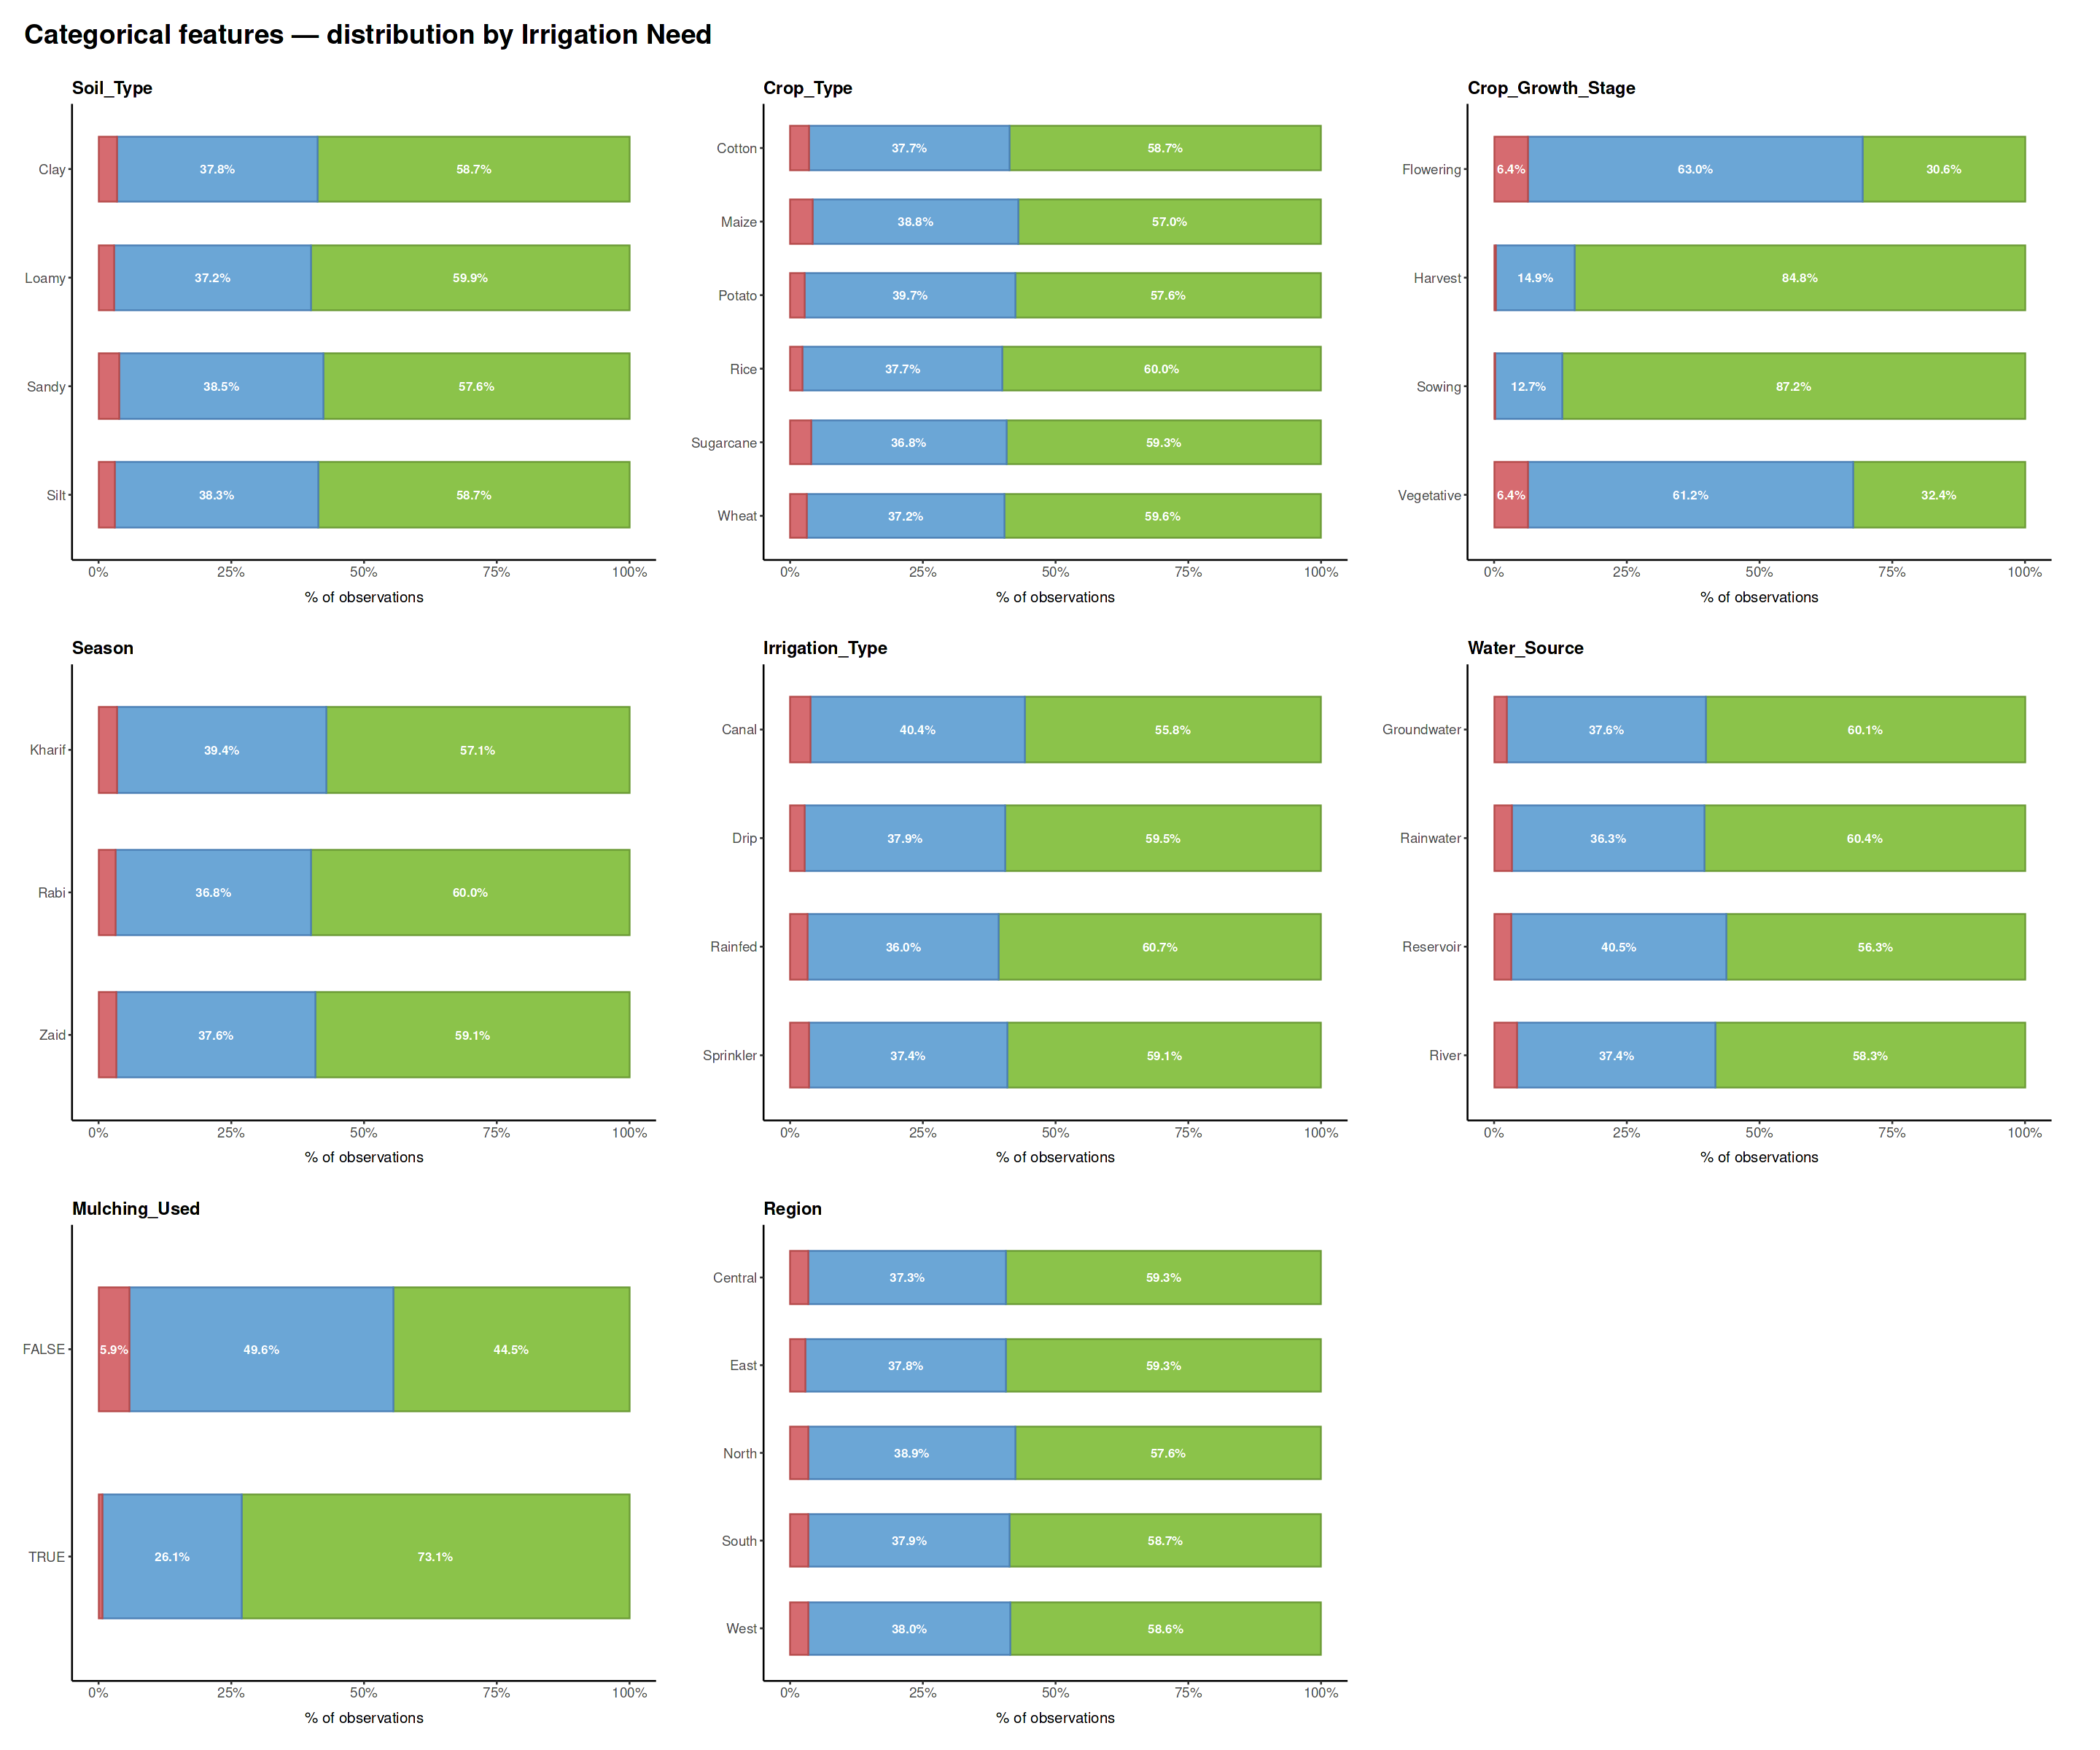

In [19]:
# Target-oriented plots

options(repr.plot.width = 24, repr.plot.height = 20)

plot_cat_target <- function(df, feature) {
  df %>%
    mutate(cat = as.character(.data[[feature]])) %>%
    count(cat, Irrigation_Need) %>%
    group_by(cat) %>%
    mutate(pct = n / sum(n) * 100) %>%
    ungroup() %>%
    ggplot(aes(y = fct_rev(cat), x = pct, fill = Irrigation_Need,
               color = Irrigation_Need)) +
    geom_col(width = 0.6, linewidth = 0.5, position = "stack") +
    geom_text(aes(label = ifelse(pct > 5, sprintf("%.1f%%", pct), "")),
              position = position_stack(vjust = 0.5),
              size = 3.5, fontface = "bold", color = "white") +
    scale_fill_manual(values  = target_fill_colors) +
    scale_color_manual(values = target_border_colors) +
    scale_x_continuous(labels = scales::label_percent(scale = 1)) +
    labs(title = feature, x = "% of observations", y = NULL,
         fill = "Irrigation Need", color = "Irrigation Need") +
    theme_classic(base_size = 12) +
    theme(
      plot.title      = element_text(face = "bold", size = 14),
      axis.title.x    = element_text(size = 12, margin = margin(t = 10)),
      axis.text       = element_text(size = 11),
      plot.margin     = margin(t = 20, r = 20, b = 10, l = 10),
      legend.position = "none"
    )
}

plots_cat_target <- map(categorical_features, ~ plot_cat_target(train, .x))

# Shared legend extracted from one plot
legend_plot <- plot_cat_target(train, "Soil_Type") +
  theme(legend.position = "bottom",
        legend.title    = element_text(size = 18, face = "bold"),
        legend.text     = element_text(size = 16))

wrap_plots(plots_cat_target, ncol = 3) +
  guide_area() +
  plot_layout(guides = "collect") +
  plot_annotation(
    title = "Categorical features — distribution by Irrigation Need",
    theme = theme(
      plot.title      = element_text(face = "bold", size = 22),
      axis.title.x = element_text(size = 14, margin = margin(t = 10)),
      axis.text    = element_text(size = 15),
      plot.margin  = margin(t = 20, r = 20, b = 10, l = 10),  
      legend.position = "bottom"
    )
  )

#### **<u>Categorical Features Conclusions</u>**

<br>

**Predictive power scale:**
&nbsp; <span style="background-color: #8BC34A; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Strong predictor</span> &nbsp;&nbsp;
<span style="background-color: #6BA6D6; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Moderate predictor</span> &nbsp;&nbsp;
<span style="background-color: #FFB74D; padding: 2px 10px; border-radius: 4px;">&nbsp;</span> <span style="color: black; font-weight: bold;">Weak predictor</span>

<br>

---

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Soil_Type</span>

* **Univariate**: Four soil types nearly equally distributed: Sandy (26.4%), Clay (25.2%), Loamy (24.8%), and Silt (23.6%). The dataset is well balanced across soil types.
* **Target relationship**: Virtually identical class distributions across all four types (~58-60% Low, ~37-38% Medium, ~3-4% High). Soil type alone does not drive irrigation need in this dataset. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Crop_Type</span>

* **Univariate**: Six crops fairly evenly distributed, ranging from Sugarcane (17.3%) to Potato (16.3%). No dominant crop type.
* **Target relationship**: Class proportions are nearly identical across all six crops (~57-60% Low, ~37-40% Medium, ~2-4% High). The specific crop being grown does not

<br>

<span style="background-color: #8BC34A; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Crop_Growth_Stage</span>

* **Univariate**: Fairly balanced across the four stages — Harvest (26.6%), Flowering (25.0%), Vegetative (25.0%), and Sowing (23.4%).
* **Target relationship**: This is the most striking categorical feature. Sowing and Harvest stages are dominated by Low irrigation need (87.2% and 84.8% respectively), while Flowering and Vegetative stages shift strongly toward Medium (63.0% and 61.2%) and accumulate more High cases (6.4% each). This reflects the agronomic reality that crops require the most water during active growth phases. 

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Season</span>

* **Univariate**: Three seasons nearly equally represented: Kharif (34.4%), Rabi (33.0%), and Zaid (32.6%).
* **Target relationship**: Minimal variation across seasons (~57-60% Low, ~37-39% Medium, ~3% High). The season alone does not determine irrigation need, likely because other features such as rainfall and temperature already capture seasonal effects.

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Irrigation_Type</span>
 
* **Univariate**: Four methods distributed evenly — Canal (25.7%), Sprinkler (25.6%), Rainfed (24.7%), and Drip (24.0%).
* **Target relationship**: Very similar class distributions across all four methods (~55-61% Low, ~36-40% Medium, ~3-4% High). The irrigation method appears to be descriptive of current practice rather than predictive of need.

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Water_Source</span>

* **Univariate**: Four sources nearly equally split — Reservoir (25.9%), River (25.4%), Groundwater (24.9%), and Rainwater (24.3%).
* **Target relationship**: Minor differences across sources. Reservoir shows the highest Medium share (40.5%) while Rainwater and Groundwater lean slightly more toward Low (60.4% and 60.1%). Differences are small and unlikely to be strongly predictive.

<br>

<span style="background-color: #8BC34A; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Mulching_Used</span>

* **Univariate**: Nearly perfectly balanced: FALSE (50.2%) and TRUE (49.8%).
* **Target relationship**: Clear and meaningful shift. Fields without mulching show a more balanced distribution (44.5% Low, 49.6% Medium, 5.9% High), while fields with mulching are strongly concentrated in Low (73.1%) with very few High cases (0.8%). This makes agronomic sense — mulching retains soil moisture, directly reducing irrigation requirements.

<br>

<span style="background-color: #FFB74D; color: black; font-weight: bold; padding: 2px 8px; border-radius: 4px;">Region</span>

* **Univariate**: Five regions with South slightly overrepresented (21.4%) and North underrepresented (18.1%), but overall reasonably balanced.
* **Target relationship**: Nearly identical class proportions across all five regions (~58-59% Low, ~37-39% Medium, ~3% High). Geographic region does not appear to carry additional predictive signal beyond what is already captured by climate and soil features.

<br>

---

#### **<u>Overall summarys</u>**

Among categorical features, **`Crop_Growth_Stage`** and **`Mulching_Used`** stand out as the only meaningful predictors. Both have a direct agronomic explanation: crops demand more water during active growth phases, and mulching retains soil moisture reducing irrigation need. 

The remaining six categorical features show near-uniform class distributions across their categories, suggesting they carry little independent predictive signal.

## **C. Multivariate feature analysis** <a class="anchor" id="multivar"></a>

### **Correlation matrix — numerical features**

In [20]:
cor_matrix <- train %>%
  select(all_of(numerical_features)) %>%
  cor(method = "pearson", use = "complete.obs") %>%
  round(3)

cor_matrix

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
Soil_pH,1.000,-0.004,-0.003,0.000,-0.002,0.001,-0.005,0.001,0.003,0.004,0.002
Soil_Moisture,-0.004,1.000,-0.015,-0.009,-0.038,0.015,0.044,0.006,-0.028,-0.005,-0.023
Organic_Carbon,-0.003,-0.015,1.000,0.011,-0.002,0.003,-0.017,0.000,0.011,-0.006,-0.001
Electrical_Conductivity,0.000,-0.009,0.011,1.000,0.004,0.000,-0.004,0.000,-0.002,0.008,0.002
Temperature_C,-0.002,-0.038,-0.002,0.004,1.000,-0.020,-0.017,-0.003,-0.002,0.011,0.008
Humidity,0.001,0.015,0.003,0.000,-0.020,1.000,0.001,0.002,0.012,0.006,0.019
Rainfall_mm,-0.005,0.044,-0.017,-0.004,-0.017,0.001,1.000,-0.006,-0.033,-0.012,0.013
Sunlight_Hours,0.001,0.006,0.000,0.000,-0.003,0.002,-0.006,1.000,0.000,-0.005,0.002
Wind_Speed_kmh,0.003,-0.028,0.011,-0.002,-0.002,0.012,-0.033,0.000,1.000,0.010,0.010
Field_Area_hectare,0.004,-0.005,-0.006,0.008,0.011,0.006,-0.012,-0.005,0.010,1.000,0.007


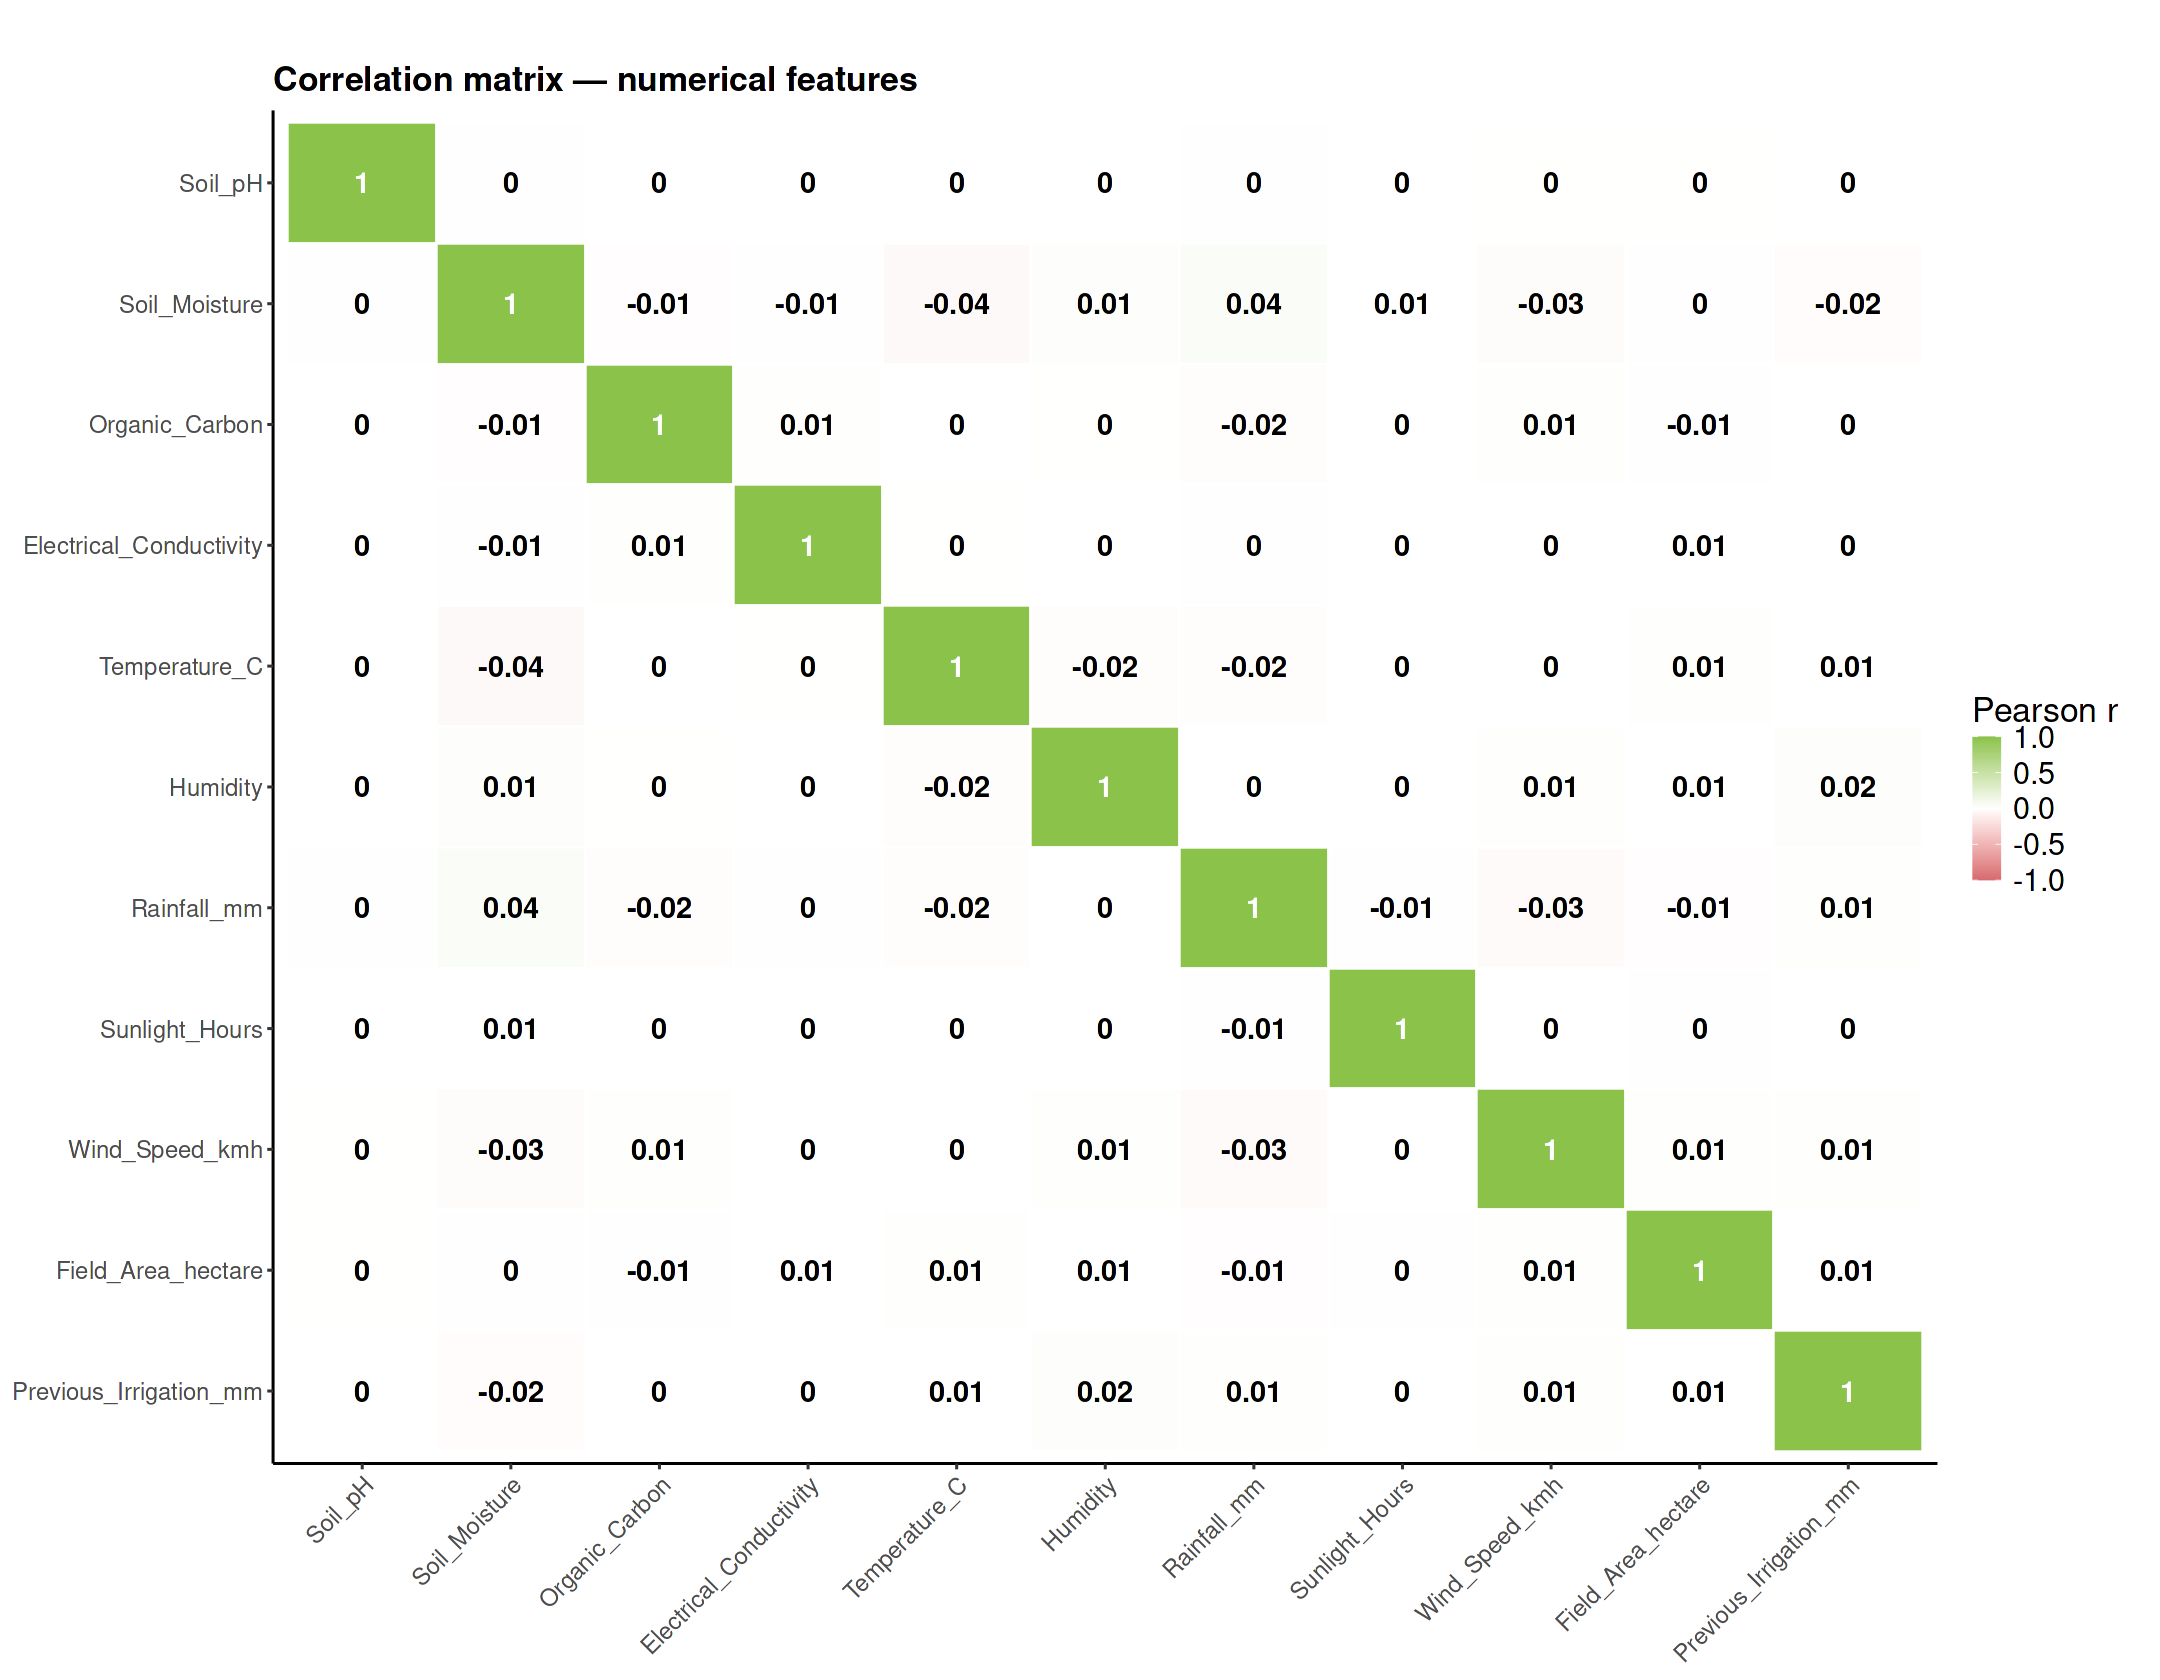

In [21]:
options(repr.plot.width = 18, repr.plot.height = 14)

# Reshape
cor_long <- cor_matrix %>%
  as.data.frame() %>%
  rownames_to_column("feature_x") %>%
  pivot_longer(-feature_x, names_to = "feature_y", values_to = "correlation") %>%
  mutate(
    feature_x = factor(feature_x, levels = numerical_features),
    feature_y = factor(feature_y, levels = rev(numerical_features)),
    label     = round(correlation, 2)
  )

# Plot
ggplot(cor_long, aes(x = feature_x, y = feature_y, fill = correlation)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = label,
                color = abs(correlation) > 0.5),
            size = 6, fontface = "bold") +
  scale_fill_gradient2(
    low      = "#D66B70",
    mid      = "white",
    high     = "#8BC34A",
    midpoint = 0,
    limits   = c(-1, 1),
    name     = "Pearson r"
  ) +
  scale_color_manual(values = c("TRUE" = "white", "FALSE" = "black"),
                     guide  = "none") +
  labs(
    title = "Correlation matrix — numerical features",
    x     = NULL,
    y     = NULL
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title   = element_text(face = "bold", size = 20),
    axis.text.x  = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y  = element_text(size = 14),
    plot.margin  = margin(t = 40, r = 20, b = 10, l = 10),
    legend.title = element_text(size = 20),
    legend.text  = element_text(size = 18)
  )

#### **<u>Correlation Numerical Features Conclusions</u>**

The correlation matrix shows extremely low correlations between all numerical features. This means:

* No multicollinearity issues. We can safely include all features in the model without worrying about redundancy.
* No need for dimensionality reduction (PCA).
* Tree-based models will have to learn interactions between features rather than relying on correlated groups

The highest absolute value is 0.044 (`Rainfall_mm` vs `Soil_Moisture`). 

### **Pairwise correlations by Irrigation Need class**

In [22]:
top_predictors <- c("Soil_Moisture", "Temperature_C", "Rainfall_mm", "Wind_Speed_kmh")

map_dfr(levels(train$Irrigation_Need), function(lvl) {
  train %>%
    filter(Irrigation_Need == lvl) %>%
    select(all_of(top_predictors)) %>%
    cor(method = "pearson", use = "complete.obs") %>%
    round(3) %>%
    as.data.frame() %>%
    rownames_to_column("feature") %>%
    mutate(Irrigation_Need = lvl) %>%
    select(Irrigation_Need, feature, everything())
}) %>%
  { options(width = 200); print(as.data.frame(.), row.names = FALSE) }

 Irrigation_Need        feature Soil_Moisture Temperature_C Rainfall_mm Wind_Speed_kmh
             Low  Soil_Moisture         1.000         0.028       0.003          0.064
             Low  Temperature_C         0.028         1.000       0.007         -0.037
             Low    Rainfall_mm         0.003         0.007       1.000         -0.008
             Low Wind_Speed_kmh         0.064        -0.037      -0.008          1.000
          Medium  Soil_Moisture         1.000         0.167      -0.011          0.162
          Medium  Temperature_C         0.167         1.000       0.023         -0.133
          Medium    Rainfall_mm        -0.011         0.023       1.000         -0.008
          Medium Wind_Speed_kmh         0.162        -0.133      -0.008          1.000
            High  Soil_Moisture         1.000         0.010      -0.096          0.003
            High  Temperature_C         0.010         1.000       0.110          0.032
            High    Rainfall_mm        -0.0

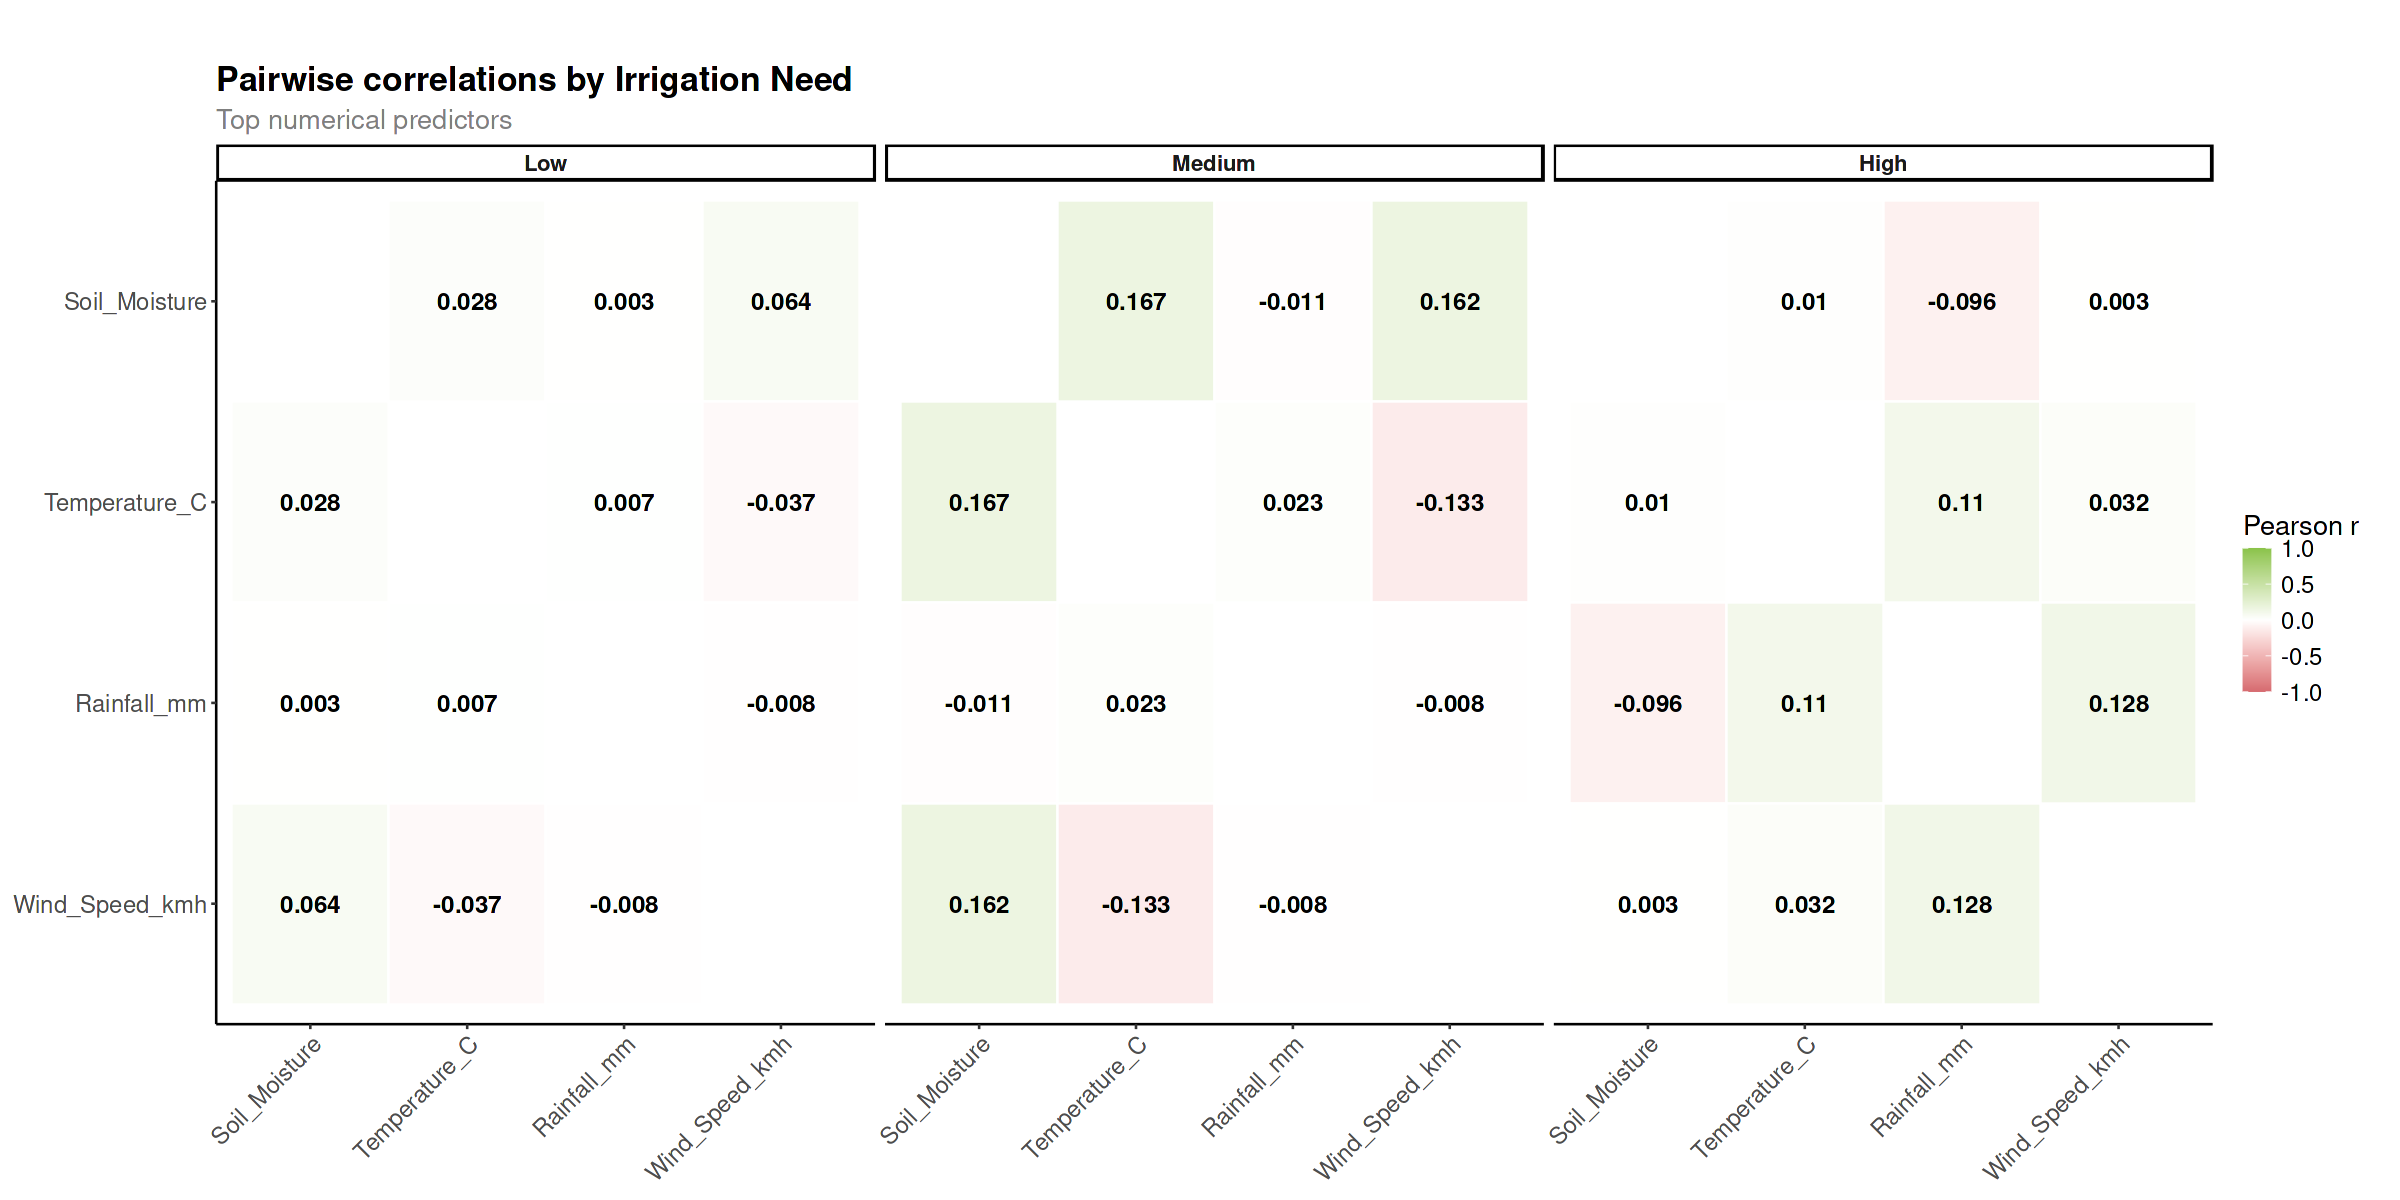

In [23]:
options(repr.plot.width = 20, repr.plot.height = 10)

map_dfr(levels(train$Irrigation_Need), function(lvl) {
  train %>%
    filter(Irrigation_Need == lvl) %>%
    select(all_of(top_predictors)) %>%
    cor(method = "pearson", use = "complete.obs") %>%
    round(3) %>%
    as.data.frame() %>%
    rownames_to_column("feature_x") %>%
    pivot_longer(-feature_x, names_to = "feature_y", values_to = "correlation") %>%
    mutate(Irrigation_Need = lvl)
}) %>%
  filter(feature_x != feature_y) %>%           # remove diagonal
  mutate(
    feature_x      = factor(feature_x,      levels = top_predictors),
    feature_y      = factor(feature_y,      levels = rev(top_predictors)),
    Irrigation_Need = factor(Irrigation_Need, levels = c("Low", "Medium", "High"))
  ) %>%
  ggplot(aes(x = feature_x, y = feature_y, fill = correlation)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = correlation),
            size = 5, fontface = "bold") +
  scale_fill_gradient2(
    low      = "#D66B70", mid= "white", high = "#8BC34A",
    midpoint = 0,
    limits   = c(-1, 1),
    name     = "Pearson r"
  ) +
  scale_color_manual(values = c("TRUE" = "white", "FALSE" = "black"),
                     guide  = "none") +
  facet_wrap(~ Irrigation_Need, ncol = 3) +
  labs(
    title    = "Pairwise correlations by Irrigation Need",
    subtitle = "Top numerical predictors",
    x        = NULL,
    y        = NULL
  ) +
  theme_classic(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold", size = 20),
    plot.subtitle = element_text(size = 16, color = "grey50"),
    axis.text.x   = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y   = element_text(size = 14),
    strip.text    = element_text(face = "bold", size = 13),
    plot.margin   = margin(t = 40, r = 20, b = 10, l = 10),
    legend.title  = element_text(size = 16),
    legend.text   = element_text(size = 14)
  )

#### **<u>Pairwise correlations by Irrigation Need class Conclusions</u>**

Splitting by class reveals subtle interaction patterns that are invisible in the overall correlation matrix:

* **Low class**. All correlations are near zero (|r| < 0.07). Features behave independently within this class.
* **Medium class**. Three moderate correlations emerge:
   * `Soil_Moisture` & `Temperature_C`. (r = 0.167).
   * `Soil_Moisture` & `Wind_Speed_kmh`. (r = 0.162).
   * `Temperature_C` ↔ `Wind_Speed_kmh`. (r = -0.133).

This suggests that within medium irrigation need scenarios, higher temperatures and wind speeds co-occur with higher soil moisture.

**High class**: Three high correlations emerge:
   * `Rainfall_mm` & `Wind_Speed_kmh`. (r = 0.128).
   * `Temperature_C` & `Rainfall_mm`. (r = 0.110).
   * `Soil_Moisture` & `Rainfall_mm`. (r = -0.096). 

This is counterintuitive but may reflect that high irrigation need occurs precisely when rainfall fails to replenish soil moisture despite occurring.

These interaction effects are better captured by tree-based models than linear ones, reinforcing our choice of XGBoost and Random Forest for modeling.

### **Categorical vs numerical interactions**

We examine whether the effect of the top numerical predictors (`Soil_Moisture`, `Temperature_C`, `Rainfall_mm`, `Wind_Speed_kmh`) differs across the two strongest categorical predictors `Crop_Growth_Stage` and `Mulching_Used`).

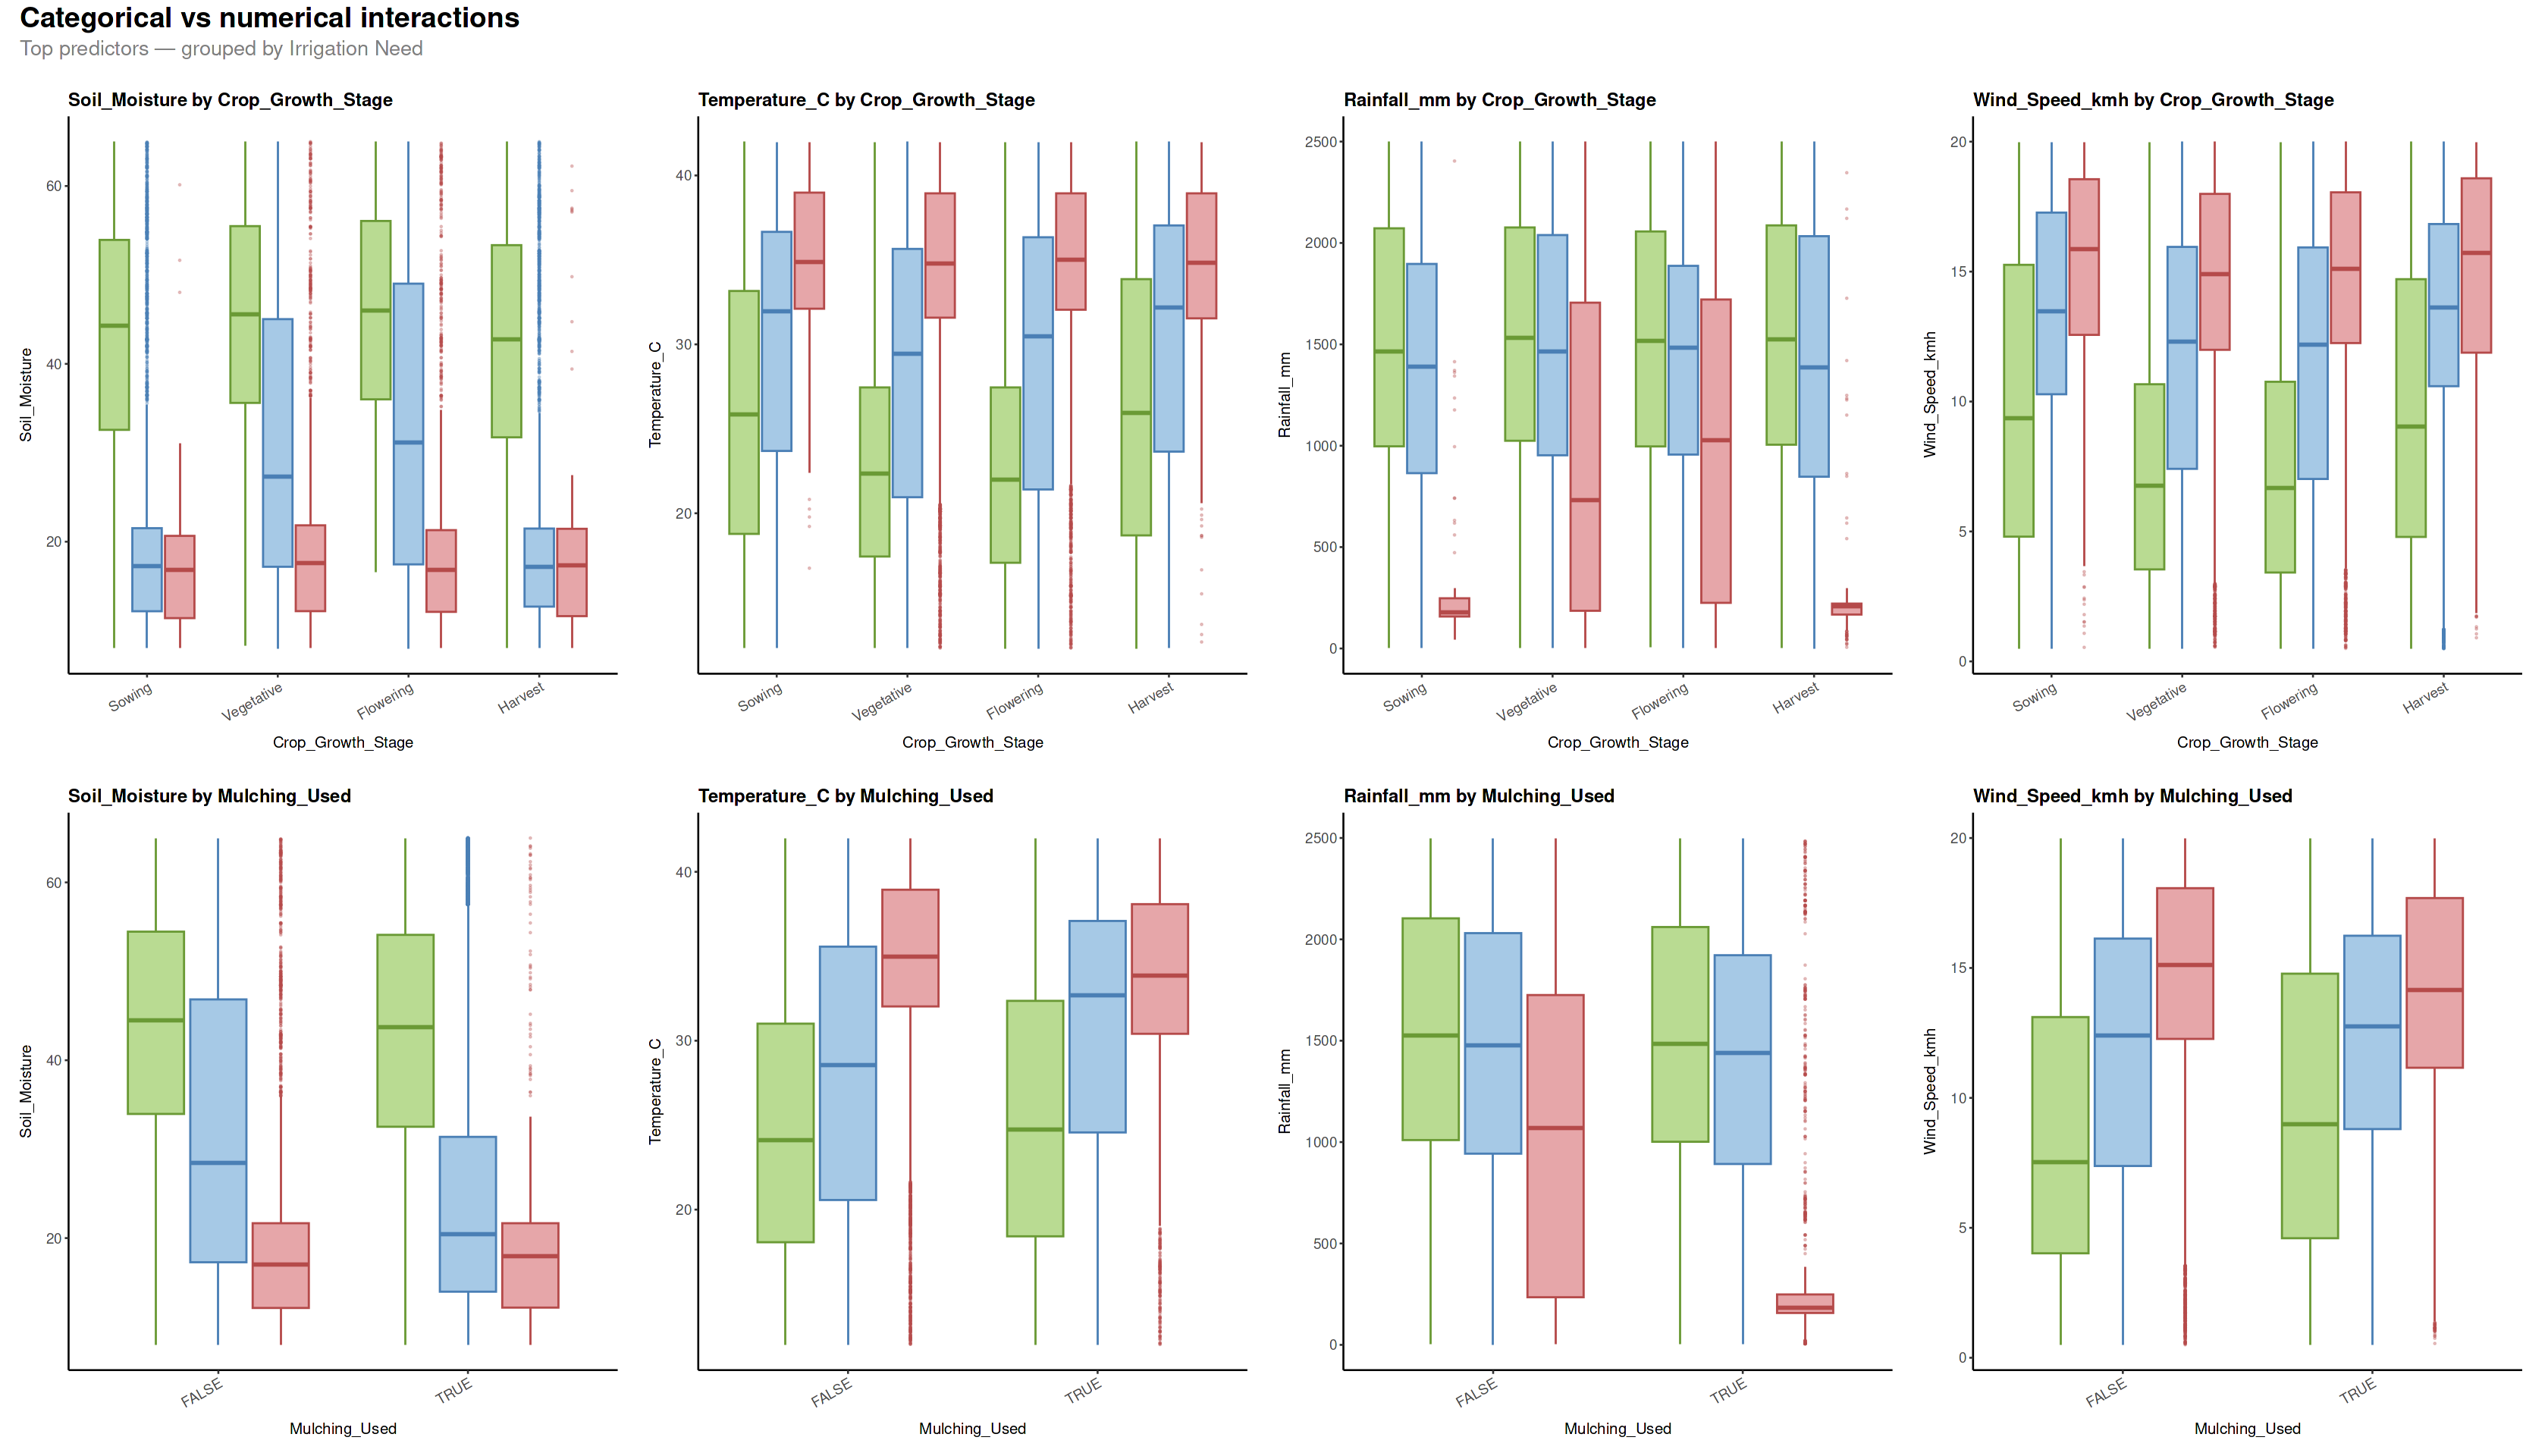

In [24]:
options(repr.plot.width = 28, repr.plot.height = 16)

plot_interaction <- function(df, num_feature, cat_feature) {
  df %>%
    ggplot(aes(x     = .data[[cat_feature]],
               y     = .data[[num_feature]],
               fill  = Irrigation_Need,
               color = Irrigation_Need)) +
    geom_boxplot(alpha       = 0.6,
                 linewidth   = 0.6,
                 outlier.size  = 0.3,
                 outlier.alpha = 0.3) +
    scale_fill_manual(values  = target_fill_colors) +
    scale_color_manual(values = target_border_colors) +
    labs(
      title = paste0(num_feature, " by ", cat_feature),
      x     = cat_feature,
      y     = num_feature,
      fill  = "Irrigation Need",
      color = "Irrigation Need"
    ) +
    theme_classic(base_size = 12) +
    theme(
      plot.title      = element_text(face = "bold", size = 14),
      axis.title.x    = element_text(size = 12, margin = margin(t = 10)),
      axis.title.y    = element_text(size = 12, margin = margin(r = 10)),
      axis.text.x     = element_text(angle = 30, hjust = 1, size = 11),
      axis.text.y     = element_text(size = 11),
      legend.position = "none",
      plot.margin     = margin(t = 20, r = 15, b = 10, l = 10)
    )
}

# Combinations

cat_features_top <- c("Crop_Growth_Stage", "Mulching_Used")

interaction_plots <- map(
  cat_features_top,
  function(cat_f) {
    map(top_predictors, ~ plot_interaction(train, .x, cat_f))
  }
) %>%
  flatten()

# Legend

shared_legend <- plot_interaction(train, "Soil_Moisture", "Crop_Growth_Stage") +
  theme(
    legend.position = "bottom",
    legend.title    = element_text(size = 13, face = "bold"),
    legend.text     = element_text(size = 12)
  )

# Final

wrap_plots(interaction_plots, ncol = 4) +
  plot_layout(guides = "collect") +
  plot_annotation(
    title    = "Categorical vs numerical interactions",
    subtitle = "Top predictors — grouped by Irrigation Need",
    theme    = theme(
      plot.title      = element_text(face = "bold", size = 22),
      plot.subtitle   = element_text(size = 16, color = "grey50"),
      legend.position = "bottom",
      legend.title    = element_text(size = 14, face = "bold"),
      legend.text     = element_text(size = 13)
    )
  )

#### **<u>Categorical vs Numerical Conclusions</u>**

<br>

**Soil_Moisture × Crop_Growth_Stage**.

The separation between classes is consistent across all growth stages. High irrigation need always corresponds to the lowest soil moisture regardless of stage. 
However, the overall moisture level is notably lower during Flowering and Vegetative stages, confirming that these are the most water-demanding phases.

**Temperature_C × Crop_Growth_Stage**.

The High class shows elevated temperatures across all stages, but the effect is most pronounced during Flowering and Vegetative, where the High boxplot sits clearly above Low and Medium. 
During Sowing and Harvest the three classes overlap more, suggesting temperature is less discriminative at those stages.

**Rainfall_mm × Crop_Growth_Stage**.

The most striking interaction. The High class shows dramatically lower rainfall across all stages, but particularly during Sowing and Flowering, where the High boxplot collapses to near zero. 
This confirms that High irrigation need is strongly driven by rainfall deficit, regardless of growth stage.

**Wind_Speed_kmh × Crop_Growth_Stage**. 

Consistent pattern across all stages. High irrigation need corresponds to higher wind speeds. The interaction with growth stage is minimal, suggesting wind speed acts independently of crop phenology.

**Soil_Moisture × Mulching_Used**. 

The class separation pattern is preserved in both mulched and non-mulched fields, but mulched fields (TRUE) show consistently lower soil moisture for the High class, suggesting that even with mulching, extreme irrigation need is associated with very dry soils.

**Temperature_C × Mulching_Used**.

Without mulching (FALSE), the three classes separate clearly by temperature. 
With mulching (TRUE), the separation is similar but the High class median temperature is slightly higher, suggesting mulching partially compensates for moderate heat but not for extreme temperatures.

**Rainfall_mm × Mulching_Used**.

The High class shows very low rainfall in both conditions, but the effect is dramatically amplified when mulching is used.
This suggests that mulched fields with very low rainfall still face extreme irrigation need despite moisture retention.

**Wind_Speed_kmh × Mulching_Used**. 

Both mulched and non-mulched fields show the same increasing wind speed pattern across Low < Medium < High. 
Mulching does not appear to buffer the effect of wind-driven evapotranspiration.

<br>

---

#### **<u>Overall summarys</u>**

The interactions confirm that `Rainfall_mm` is the most powerful feature in combination with both categorical predictors.

`Soil_Moisture` and `Temperature_C` also show meaningful interactions, particularly with `Crop_Growth_Stage`. 

These interaction effects strongly favour tree-based models such as XGBoost and Random Forest, which can capture them naturally without explicit feature engineering.

# **🔧 3. Feature Engineering** <a class="anchor" id="fe"></a>

In [25]:
# XGBoost: Dummy encoding + numerical

recipe_xgb <- recipe(Irrigation_Need ~ ., data = train) %>%
  step_rm(id) %>%
  step_novel(all_nominal_predictors()) %>%
  step_dummy(all_nominal_predictors(), one_hot = TRUE) %>%
  step_mutate(Mulching_Used = as.integer(Mulching_Used))

In [26]:
# LightGBM: Factors handled natively

recipe_lgbm <- recipe(Irrigation_Need ~ ., data = train) %>%
  step_rm(id) %>%
  step_novel(all_nominal_predictors())

In [27]:
# Random Forest: Factors handled natively

recipe_rf <- recipe(Irrigation_Need ~ ., data = train) %>%
  step_rm(id) %>%
  step_novel(all_nominal_predictors())

# **✂️ 4. Data preparation & resampling strategy** <a class="anchor" id="prep"></a>

Before training, we define the resampling strategy that will be used to evaluate and compare all three models. 

Since the competition metric is **balanced accuracy**, we must ensure every fold is representative of all three classes — especially `High`, which represents only 3.3% of observations.

**Metrics to track** during cross-validation:

* `bal_accuracy` is the competition metric.
* `accuracy` and `roc_auc` are tracked as secondary diagnostics.

In [28]:
# Stratified sample for tuning (10% of data)
train_tune <- train %>%
  group_by(Irrigation_Need) %>%
  sample_frac(0.1) %>%
  ungroup()

cat("Tuning sample size:", nrow(train_tune), "rows\n")
cat("Class distribution:\n")
train_tune %>%
  count(Irrigation_Need) %>%
  mutate(pct = round(n / sum(n) * 100, 2)) %>%
  print()

# 10-fold stratified cross-validation
cv_folds_tune <- vfold_cv(
  data   = train_tune,
  v      = 10,
  strata = Irrigation_Need
)

Tuning sample size: 63000 rows


Class distribution:


# A tibble: 3 × 3
  Irrigation_Need     n   pct
  <ord>           <int> <dbl>
1 Low             36992 58.7 
2 Medium          23907 38.0 
3 High             2101  3.33


In [29]:
# Metrics
irrigation_metrics <- metric_set(
  bal_accuracy,
  accuracy,
  roc_auc
)

# **🧠 5. Modeling** <a class="anchor" id="model"></a>

**Models**:

* XGBoost.
* LightGBM.
* Random Forest.

Hyperparameters are tuned using Bayesian optimization to efficiently explore the parameter space.

## **A. Model specification**<a class="anchor" id="spec"></a>

In [30]:
# XGBoost
spec_xgb <- boost_tree(
  trees          = tune(),
  tree_depth     = tune(),
  learn_rate     = tune(),
  min_n          = tune(),
  loss_reduction = tune(),
  sample_size    = tune(),
  mtry           = tune(),
  stop_iter      = 20
) %>%
  set_engine("xgboost") %>%
  set_mode("classification")

# LightGBM
spec_lgbm <- boost_tree(
  trees       = tune(),
  tree_depth  = tune(),
  learn_rate  = tune(),
  min_n       = tune(),
  sample_size = tune(),
  mtry        = tune()
) %>%
  set_engine("lightgbm") %>%
  set_mode("classification")

# Random Forest
spec_rf <- rand_forest(
  trees = tune(),
  mtry  = tune(),
  min_n = tune()
) %>%
  set_engine("ranger",
             importance  = "impurity",
             num.threads = 1) %>%
  set_mode("classification")

In [31]:
# WORKFLOWS

# XGBoost
wf_xgb <- workflow() %>%
  add_recipe(recipe_xgb) %>%
  add_model(spec_xgb)

# LightGBM
wf_lgbm <- workflow() %>%
  add_recipe(recipe_lgbm) %>%
  add_model(spec_lgbm)

#  Random Forest
wf_rf <- workflow() %>%
  add_recipe(recipe_rf) %>%
  add_model(spec_rf)

In [32]:
# XGBoost

params_xgb <- tibble(
  trees          = 1000,
  tree_depth     = 6,
  learn_rate     = 0.05,
  min_n          = 10,
  loss_reduction = 0,
  sample_size    = 0.8,
  mtry           = 10
)
 
wf_xgb_final <- finalize_workflow(wf_xgb, params_xgb)

In [33]:
# LightGBM

params_lgbm <- tibble(
  trees       = 1000,
  tree_depth  = 6,
  learn_rate  = 0.05,
  min_n       = 20,
  sample_size = 0.8,
  mtry        = 8
)
 
wf_lgbm_final <- finalize_workflow(wf_lgbm, params_lgbm)

In [34]:
# Random Forest

params_rf <- tibble(
  trees = 500,
  mtry  = 5,
  min_n = 5
)
 
wf_rf_final <- finalize_workflow(wf_rf, params_rf)

## **B. Cross-validation evaluation**<a class="anchor" id="cve"></a>

We evaluate each finalized model using the same tuning folds (cv_folds_tune) and metric set (irrigation_metrics) defined earlier.    

In [35]:
# We set save_pred = TRUE so we can later inspect per-class performance.
ctrl <- control_resamples(save_pred = TRUE)

In [36]:
# XGBoost 

cv_xgb <- fit_resamples(
  wf_xgb_final,
  resamples = cv_folds_tune,
  metrics   = irrigation_metrics,
  control   = ctrl
)

In [37]:
# LightGBM 

cv_lgbm <- fit_resamples(
  wf_lgbm_final,
  resamples = cv_folds_tune,
  metrics   = irrigation_metrics,
  control   = ctrl
)

In [38]:
# Random Forest

cv_rf <- fit_resamples(
  wf_rf_final,
  resamples = cv_folds_tune,
  metrics   = irrigation_metrics,
  control   = ctrl
)

## **C. Compare models**<a class="anchor" id="compare"></a>


In [39]:
# Balanced accuracy for each model
metrics_xgb  <- collect_metrics(cv_xgb)  %>% mutate(model = "XGBoost")
metrics_lgbm <- collect_metrics(cv_lgbm) %>% mutate(model = "LightGBM")
metrics_rf   <- collect_metrics(cv_rf)   %>% mutate(model = "Random Forest")


all_metrics <- bind_rows(metrics_xgb, metrics_lgbm, metrics_rf)

In [40]:
cat("\nCross-validation results\n")
all_metrics %>%
  select(model, .metric, mean, std_err) %>%
  mutate(across(where(is.numeric), ~ round(., 4))) %>%
  arrange(.metric, desc(mean)) %>%
  { options(width = 120); print(as.data.frame(.), row.names = FALSE) }


Cross-validation results


         model      .metric   mean std_err
       XGBoost     accuracy 0.9848  0.0003
 Random Forest     accuracy 0.9844  0.0003
      LightGBM     accuracy 0.9831  0.0004
       XGBoost bal_accuracy 0.9733  0.0012
 Random Forest bal_accuracy 0.9721  0.0014
      LightGBM bal_accuracy 0.9716  0.0011
       XGBoost      roc_auc 0.9947  0.0004
      LightGBM      roc_auc 0.9936  0.0004
 Random Forest      roc_auc 0.9911  0.0006


# **🏆 6. Final model** <a class="anchor" id="fm"></a>

**Final model**: XGBoost.

In [41]:
# Fit final model
final_fit_xgb <- wf_xgb_final %>%
  fit(data = train)

# **🚀 7. Submission** <a class="anchor" id="sub"></a>


In [42]:
submission <- test %>%
  select(id) %>%
  bind_cols(predict(final_fit_xgb, new_data = test, type = "class")) %>%
  rename(Irrigation_Need = .pred_class)

In [43]:
write_csv(submission, "submission.csv")